# LLM Baselines Results Visualization

This notebook visualizes the results from the LLM baselines evaluation pipeline, answering key questions:

1. **Which model is best?** - Compare all 12 models across multiple metrics
2. **Baseline vs Embedding Selection?** - Compare top1_baseline vs top1_embedding methods
3. **Targetonly vs Withsub?** - Compare performance with and without subconcepts

**Additional Insights:**
- Model consistency analysis
- Target difficulty analysis
- Failure analysis

In [11]:
# Cell 1: Setup, Imports, and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# THESIS COLOR SCHEME
# =============================================================================
COLORS = {
    'primary': '#4682B4',      # Steel Blue
    'secondary': '#FF7F50',    # Coral Orange
    'accent1': '#5A9BD4',      # Light Steel Blue
    'accent2': '#FF9966',      # Light Coral
    'dark': '#2F5496',         # Dark Steel Blue
    'text': '#333333',         # Dark Gray
    'light': '#B0C4DE',        # Light Steel Blue (muted)
}

# Palette for 12 models (alternating steel blue and coral variations)
PALETTE_MAIN = ['#4682B4', '#FF7F50', '#5A9BD4', '#FF9966',
                '#6495ED', '#FFA07A', '#87CEEB', '#FA8072', 
                '#4169E1', '#CD5C5C', '#2F5496', '#E9967A']

# Set matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

# =============================================================================
# LOAD DATA
# =============================================================================
RESULTS_DIR = Path('results')
OUTPUT_DIR = RESULTS_DIR / 'visualizations'
OUTPUT_DIR.mkdir(exist_ok=True)

# Load both result files
df_targetonly = pd.read_csv(RESULTS_DIR / 'all_results_targetonly.csv')
df_withsub = pd.read_csv(RESULTS_DIR / 'all_results_withsub.csv')

# Combine into single dataframe
df = pd.concat([df_targetonly, df_withsub], ignore_index=True)

print(f"Loaded {len(df_targetonly)} targetonly records and {len(df_withsub)} withsub records")
print(f"Total: {len(df)} records")
print(f"Models: {df['model'].nunique()} - {sorted(df['model'].unique())}")

# =============================================================================
# PARSE JSON COLUMNS AND EXTRACT METRICS
# =============================================================================
def safe_json_parse(x):
    """Safely parse JSON string"""
    if pd.isna(x):
        return {}
    try:
        if isinstance(x, dict):
            return x
        return json.loads(x)
    except:
        return {}

# Parse judge columns
df['judge_baseline_parsed'] = df['judge_baseline'].apply(safe_json_parse)
df['judge_embedding_parsed'] = df['judge_embedding'].apply(safe_json_parse)

# Extract judge average scores
df['judge_baseline_avg'] = df['judge_baseline_parsed'].apply(lambda x: x.get('average', np.nan))
df['judge_embedding_avg'] = df['judge_embedding_parsed'].apply(lambda x: x.get('average', np.nan))

# Extract individual judge scores
df['baseline_coherence'] = df['judge_baseline_parsed'].apply(lambda x: x.get('coherence', np.nan))
df['baseline_mapping'] = df['judge_baseline_parsed'].apply(lambda x: x.get('mapping', np.nan))
df['baseline_explanatory'] = df['judge_baseline_parsed'].apply(lambda x: x.get('explanatory', np.nan))

df['embedding_coherence'] = df['judge_embedding_parsed'].apply(lambda x: x.get('coherence', np.nan))
df['embedding_mapping'] = df['judge_embedding_parsed'].apply(lambda x: x.get('mapping', np.nan))
df['embedding_explanatory'] = df['judge_embedding_parsed'].apply(lambda x: x.get('explanatory', np.nan))

# =============================================================================
# COMPUTE HIT@K METRICS
# =============================================================================
def compute_hit_at_k(ranks_col, k):
    """Compute Hit@K: percentage where best_rank <= k and rank != -1"""
    valid = (ranks_col >= 1) & (ranks_col <= k)
    return valid.sum() / len(ranks_col) * 100

# Add Hit@K columns
for k in [1, 3, 5, 10, 20]:
    df[f'hit_exact_{k}'] = ((df['best_exact_rank'] >= 1) & (df['best_exact_rank'] <= k)).astype(int)
    df[f'hit_sem_{k}'] = ((df['best_sem_rank'] >= 1) & (df['best_sem_rank'] <= k)).astype(int)

# Failure indicator
df['exact_match_found'] = (df['best_exact_rank'] >= 1).astype(int)
df['sem_match_found'] = (df['best_sem_rank'] >= 1).astype(int)

print("\nData preparation complete!")
print(f"Judge Baseline Avg - Mean: {df['judge_baseline_avg'].mean():.3f}, Valid: {df['judge_baseline_avg'].notna().sum()}")
print(f"Judge Embedding Avg - Mean: {df['judge_embedding_avg'].mean():.3f}, Valid: {df['judge_embedding_avg'].notna().sum()}")

Loaded 3852 targetonly records and 3852 withsub records
Total: 7704 records
Models: 12 - ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano', 'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct', 'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct', 'qwen3-14b', 'qwen3-32b']

Data preparation complete!
Judge Baseline Avg - Mean: 2.603, Valid: 7704
Judge Embedding Avg - Mean: 2.341, Valid: 7704


## Cell 2: Summary Metrics Table

Aggregate all metrics by model and mode for easy comparison.

In [12]:
# Cell 2: Create Summary Metrics Table

def compute_summary_metrics(group_df):
    """Compute all summary metrics for a group"""
    n = len(group_df)
    return pd.Series({
        # Hit@K (Exact Match)
        'Hit@1 (Exact)': group_df['hit_exact_1'].sum() / n * 100,
        'Hit@3 (Exact)': group_df['hit_exact_3'].sum() / n * 100,
        'Hit@5 (Exact)': group_df['hit_exact_5'].sum() / n * 100,
        'Hit@10 (Exact)': group_df['hit_exact_10'].sum() / n * 100,
        'Hit@20 (Exact)': group_df['hit_exact_20'].sum() / n * 100,
        
        # Hit@K (Semantic Match)
        'Hit@1 (Sem)': group_df['hit_sem_1'].sum() / n * 100,
        'Hit@3 (Sem)': group_df['hit_sem_3'].sum() / n * 100,
        'Hit@5 (Sem)': group_df['hit_sem_5'].sum() / n * 100,
        'Hit@10 (Sem)': group_df['hit_sem_10'].sum() / n * 100,
        'Hit@20 (Sem)': group_df['hit_sem_20'].sum() / n * 100,
        
        # Judge Scores (Baseline Selection)
        'Judge Avg (Baseline)': group_df['judge_baseline_avg'].mean(),
        'Coherence (Baseline)': group_df['baseline_coherence'].mean(),
        'Mapping (Baseline)': group_df['baseline_mapping'].mean(),
        'Explanatory (Baseline)': group_df['baseline_explanatory'].mean(),
        
        # Judge Scores (Embedding Selection)
        'Judge Avg (Embedding)': group_df['judge_embedding_avg'].mean(),
        'Coherence (Embedding)': group_df['embedding_coherence'].mean(),
        'Mapping (Embedding)': group_df['embedding_mapping'].mean(),
        'Explanatory (Embedding)': group_df['embedding_explanatory'].mean(),
        
        # Embedding Similarity Score
        'Top1 Embedding Score': group_df['top1_embedding_score'].mean(),
        
        # Failure Rate
        'Exact Match Rate': group_df['exact_match_found'].sum() / n * 100,
        'Sem Match Rate': group_df['sem_match_found'].sum() / n * 100,
        
        # Record count
        'N': n
    })

# Compute summary by model and mode
summary_df = df.groupby(['model', 'mode']).apply(compute_summary_metrics).reset_index()

# Display formatted table
print("=" * 100)
print("SUMMARY METRICS BY MODEL AND MODE")
print("=" * 100)

# Show key metrics
key_cols = ['model', 'mode', 'Hit@1 (Exact)', 'Hit@3 (Exact)', 'Hit@1 (Sem)', 'Hit@3 (Sem)', 
            'Judge Avg (Baseline)', 'Judge Avg (Embedding)', 'Exact Match Rate', 'N']
display_df = summary_df[key_cols].round(2)
print(display_df.to_string(index=False))

# Also create a pivot for easier viewing
print("\n" + "=" * 100)
print("PIVOT: HIT@1 (EXACT) BY MODEL AND MODE")
print("=" * 100)
pivot_hit1 = summary_df.pivot(index='model', columns='mode', values='Hit@1 (Exact)').round(2)
print(pivot_hit1)

print("\n" + "=" * 100)
print("PIVOT: JUDGE AVERAGE (BASELINE) BY MODEL AND MODE")
print("=" * 100)
pivot_judge = summary_df.pivot(index='model', columns='mode', values='Judge Avg (Baseline)').round(3)
print(pivot_judge)

# Store for later use
summary_df.to_csv(OUTPUT_DIR / 'summary_metrics_full.csv', index=False)
print(f"\nSummary saved to {OUTPUT_DIR / 'summary_metrics_full.csv'}")

SUMMARY METRICS BY MODEL AND MODE
                      model       mode  Hit@1 (Exact)  Hit@3 (Exact)  Hit@1 (Sem)  Hit@3 (Sem)  Judge Avg (Baseline)  Judge Avg (Embedding)  Exact Match Rate     N
                deepseek-r1 targetonly           7.48          10.28        15.26        23.05                  2.70                   2.47             17.13 321.0
                deepseek-r1    withsub           9.66          13.08        18.69        27.73                  2.68                   2.44             24.30 321.0
      gemini-2.5-flash-lite targetonly           7.17          10.59        15.89        26.79                  2.69                   2.38             21.81 321.0
      gemini-2.5-flash-lite    withsub           7.48          11.84        19.00        31.46                  2.67                   2.39             25.86 321.0
               gpt-4.1-mini targetonly           8.72          13.71        14.02        24.61                  2.64                   2.29       

## Cell 3: Question 1 - Which Model is Best?

Compare all 12 models across multiple metrics to determine overall best performer.

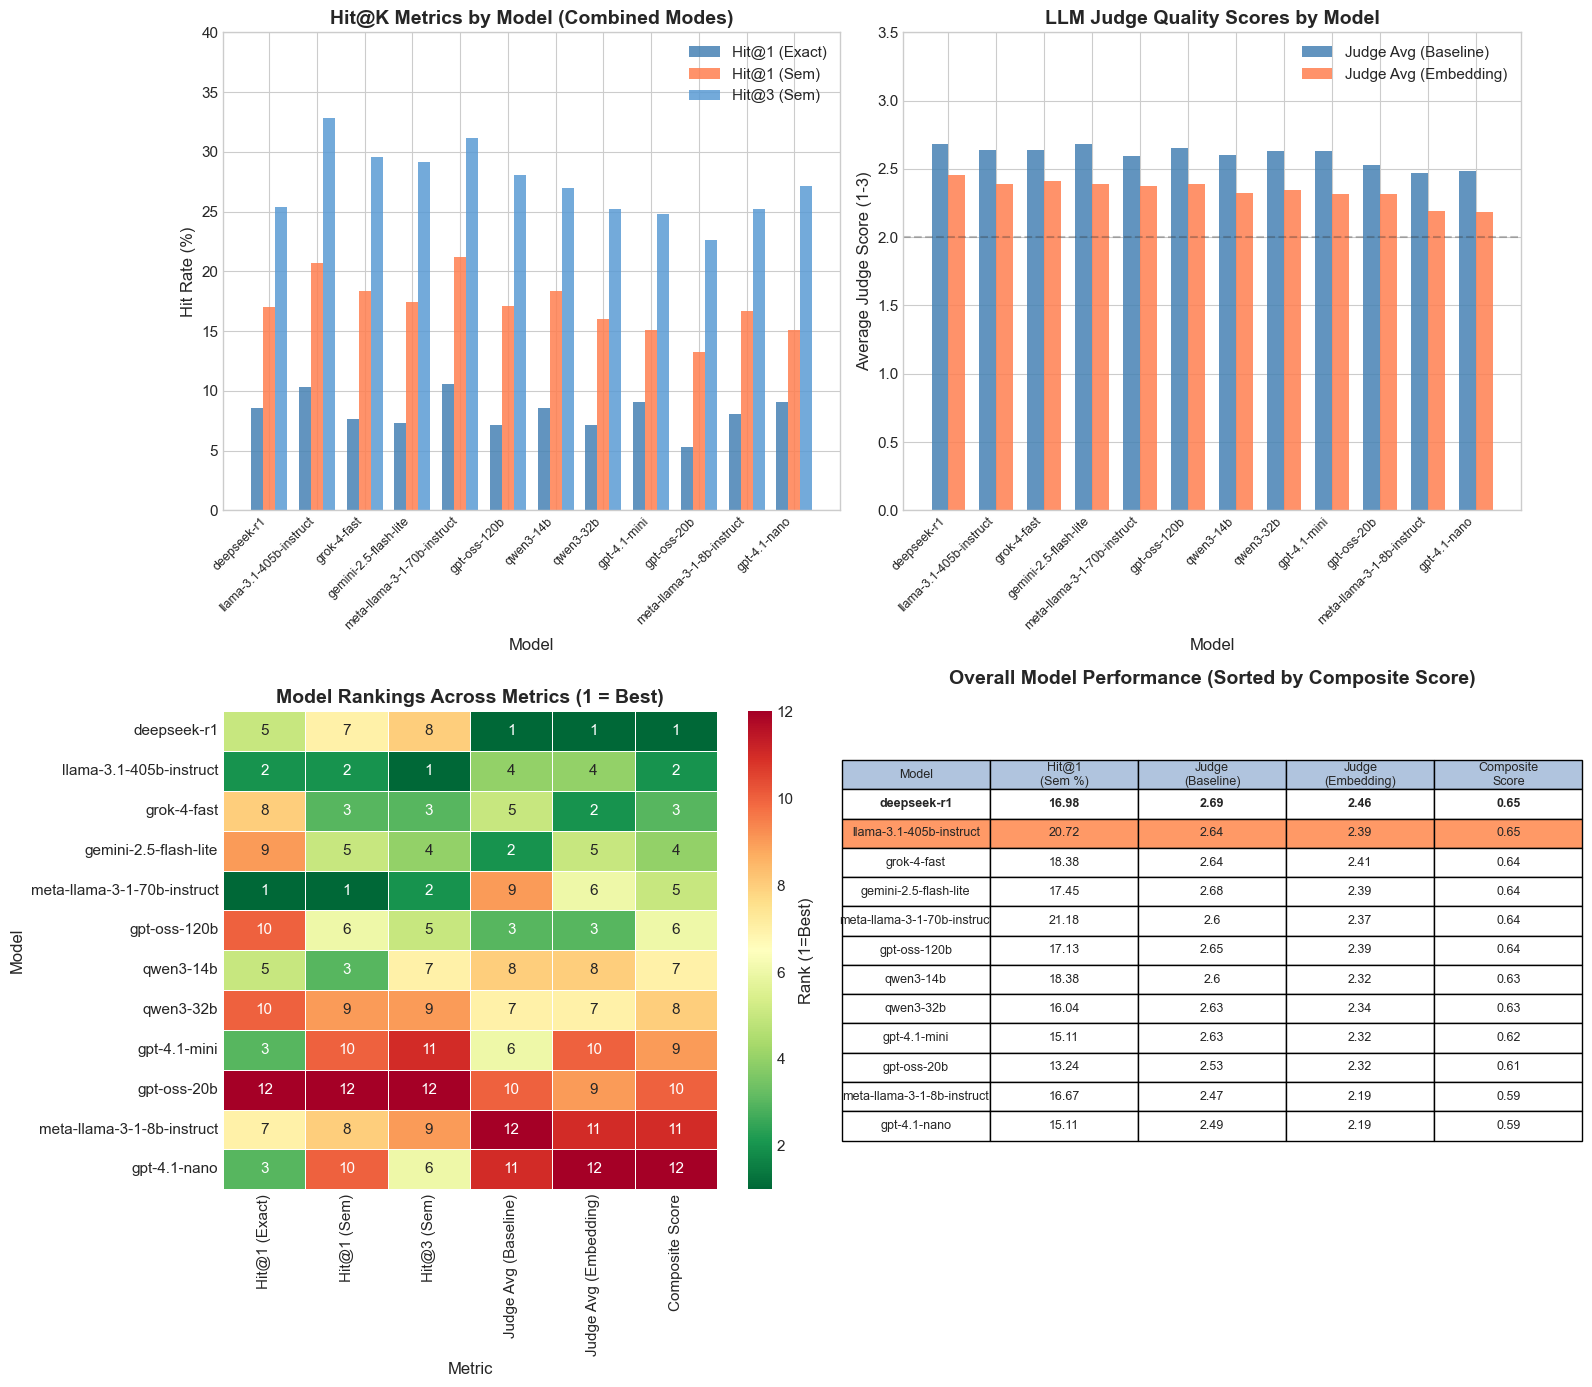


KEY FINDINGS: WHICH MODEL IS BEST?

1. BEST OVERALL MODEL: deepseek-r1
   - Composite Score: 0.651
   - Hit@1 (Semantic): 17.0%
   - Judge Avg (Baseline): 2.686

2. TOP 3 MODELS:
   1. deepseek-r1: Composite=0.651, Hit@1(Sem)=17.0%
   2. llama-3.1-405b-instruct: Composite=0.649, Hit@1(Sem)=20.7%
   3. grok-4-fast: Composite=0.644, Hit@1(Sem)=18.4%

3. BOTTOM 3 MODELS:
   10. gpt-oss-20b: Composite=0.605, Hit@1(Sem)=13.2%
   11. meta-llama-3-1-8b-instruct: Composite=0.594, Hit@1(Sem)=16.7%
   12. gpt-4.1-nano: Composite=0.591, Hit@1(Sem)=15.1%


In [13]:
# Cell 3: Which Model is Best?

# Aggregate by model (combine both modes for overall comparison)
model_summary = df.groupby('model').apply(compute_summary_metrics).reset_index()

# Sort models by a composite metric (average of key metrics)
model_summary['Composite Score'] = (
    model_summary['Hit@1 (Sem)'] / 100 * 0.3 +  # 30% weight on semantic match
    model_summary['Judge Avg (Baseline)'] / 3 * 0.35 +  # 35% weight on baseline judge
    model_summary['Judge Avg (Embedding)'] / 3 * 0.35   # 35% weight on embedding judge
)
model_summary = model_summary.sort_values('Composite Score', ascending=False)
model_order = model_summary['model'].tolist()

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# =============================================================================
# Plot 1: Multi-metric Bar Chart (Key Metrics)
# =============================================================================
ax1 = axes[0, 0]
metrics_to_plot = ['Hit@1 (Exact)', 'Hit@1 (Sem)', 'Hit@3 (Sem)']
x = np.arange(len(model_order))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    values = [model_summary[model_summary['model'] == m][metric].values[0] for m in model_order]
    bars = ax1.bar(x + i * width, values, width, label=metric, 
                   color=[COLORS['primary'], COLORS['secondary'], COLORS['accent1']][i], alpha=0.85)

ax1.set_xlabel('Model')
ax1.set_ylabel('Hit Rate (%)')
ax1.set_title('Hit@K Metrics by Model (Combined Modes)')
ax1.set_xticks(x + width)
ax1.set_xticklabels(model_order, rotation=45, ha='right', fontsize=9)
ax1.legend(loc='upper right')
ax1.set_ylim(0, max(model_summary['Hit@3 (Sem)'].max() * 1.15, 40))

# =============================================================================
# Plot 2: Judge Scores Comparison
# =============================================================================
ax2 = axes[0, 1]
width = 0.35
judge_baseline = [model_summary[model_summary['model'] == m]['Judge Avg (Baseline)'].values[0] for m in model_order]
judge_embedding = [model_summary[model_summary['model'] == m]['Judge Avg (Embedding)'].values[0] for m in model_order]

bars1 = ax2.bar(x - width/2, judge_baseline, width, label='Judge Avg (Baseline)', color=COLORS['primary'], alpha=0.85)
bars2 = ax2.bar(x + width/2, judge_embedding, width, label='Judge Avg (Embedding)', color=COLORS['secondary'], alpha=0.85)

ax2.set_xlabel('Model')
ax2.set_ylabel('Average Judge Score (1-3)')
ax2.set_title('LLM Judge Quality Scores by Model')
ax2.set_xticks(x)
ax2.set_xticklabels(model_order, rotation=45, ha='right', fontsize=9)
ax2.legend(loc='upper right')
ax2.set_ylim(0, 3.5)
ax2.axhline(y=2, color=COLORS['text'], linestyle='--', alpha=0.3, label='Threshold')

# =============================================================================
# Plot 3: Model Ranking Heatmap
# =============================================================================
ax3 = axes[1, 0]

# Create ranking dataframe
ranking_metrics = ['Hit@1 (Exact)', 'Hit@1 (Sem)', 'Hit@3 (Sem)', 
                   'Judge Avg (Baseline)', 'Judge Avg (Embedding)', 'Composite Score']
ranking_df = model_summary[['model'] + ranking_metrics].set_index('model')

# Rank models for each metric (1 = best)
ranks = ranking_df.rank(ascending=False, method='min').astype(int)

# Reorder by composite score
ranks = ranks.loc[model_order]

# Create heatmap
sns.heatmap(ranks, annot=True, cmap='RdYlGn_r', center=6.5, 
            fmt='d', linewidths=0.5, ax=ax3, cbar_kws={'label': 'Rank (1=Best)'})
ax3.set_title('Model Rankings Across Metrics (1 = Best)')
ax3.set_xlabel('Metric')
ax3.set_ylabel('Model')

# =============================================================================
# Plot 4: Overall Performance Summary Table
# =============================================================================
ax4 = axes[1, 1]
ax4.axis('off')

# Create summary table
summary_table = model_summary[['model', 'Hit@1 (Sem)', 'Judge Avg (Baseline)', 
                                'Judge Avg (Embedding)', 'Composite Score']].copy()
summary_table = summary_table.round(2)
summary_table.columns = ['Model', 'Hit@1\n(Sem %)', 'Judge\n(Baseline)', 'Judge\n(Embedding)', 'Composite\nScore']

# Create table
table = ax4.table(cellText=summary_table.values,
                  colLabels=summary_table.columns,
                  cellLoc='center',
                  loc='center',
                  colColours=[COLORS['light']] * len(summary_table.columns))

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

# Highlight best model
for i, cell in enumerate(table.get_celld().values()):
    if i < len(summary_table.columns):  # Header row
        cell.set_text_props(weight='bold')
    if i >= len(summary_table.columns) and i < len(summary_table.columns) * 2:  # First data row (best model)
        cell.set_facecolor(COLORS['accent2'])

ax4.set_title('Overall Model Performance (Sorted by Composite Score)', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print key findings
print("\n" + "=" * 80)
print("KEY FINDINGS: WHICH MODEL IS BEST?")
print("=" * 80)
print(f"\n1. BEST OVERALL MODEL: {model_order[0]}")
print(f"   - Composite Score: {model_summary[model_summary['model'] == model_order[0]]['Composite Score'].values[0]:.3f}")
print(f"   - Hit@1 (Semantic): {model_summary[model_summary['model'] == model_order[0]]['Hit@1 (Sem)'].values[0]:.1f}%")
print(f"   - Judge Avg (Baseline): {model_summary[model_summary['model'] == model_order[0]]['Judge Avg (Baseline)'].values[0]:.3f}")

print(f"\n2. TOP 3 MODELS:")
for i, model in enumerate(model_order[:3]):
    row = model_summary[model_summary['model'] == model]
    print(f"   {i+1}. {model}: Composite={row['Composite Score'].values[0]:.3f}, Hit@1(Sem)={row['Hit@1 (Sem)'].values[0]:.1f}%")

print(f"\n3. BOTTOM 3 MODELS:")
for i, model in enumerate(model_order[-3:]):
    row = model_summary[model_summary['model'] == model]
    print(f"   {i+10}. {model}: Composite={row['Composite Score'].values[0]:.3f}, Hit@1(Sem)={row['Hit@1 (Sem)'].values[0]:.1f}%")

## Cell 4: Question 2 - Baseline vs Embedding Selection

Compare the two selection methods:
- **Baseline Selection**: First analogy generated by the LLM (model order)
- **Embedding Selection**: Analogy with highest semantic similarity to target

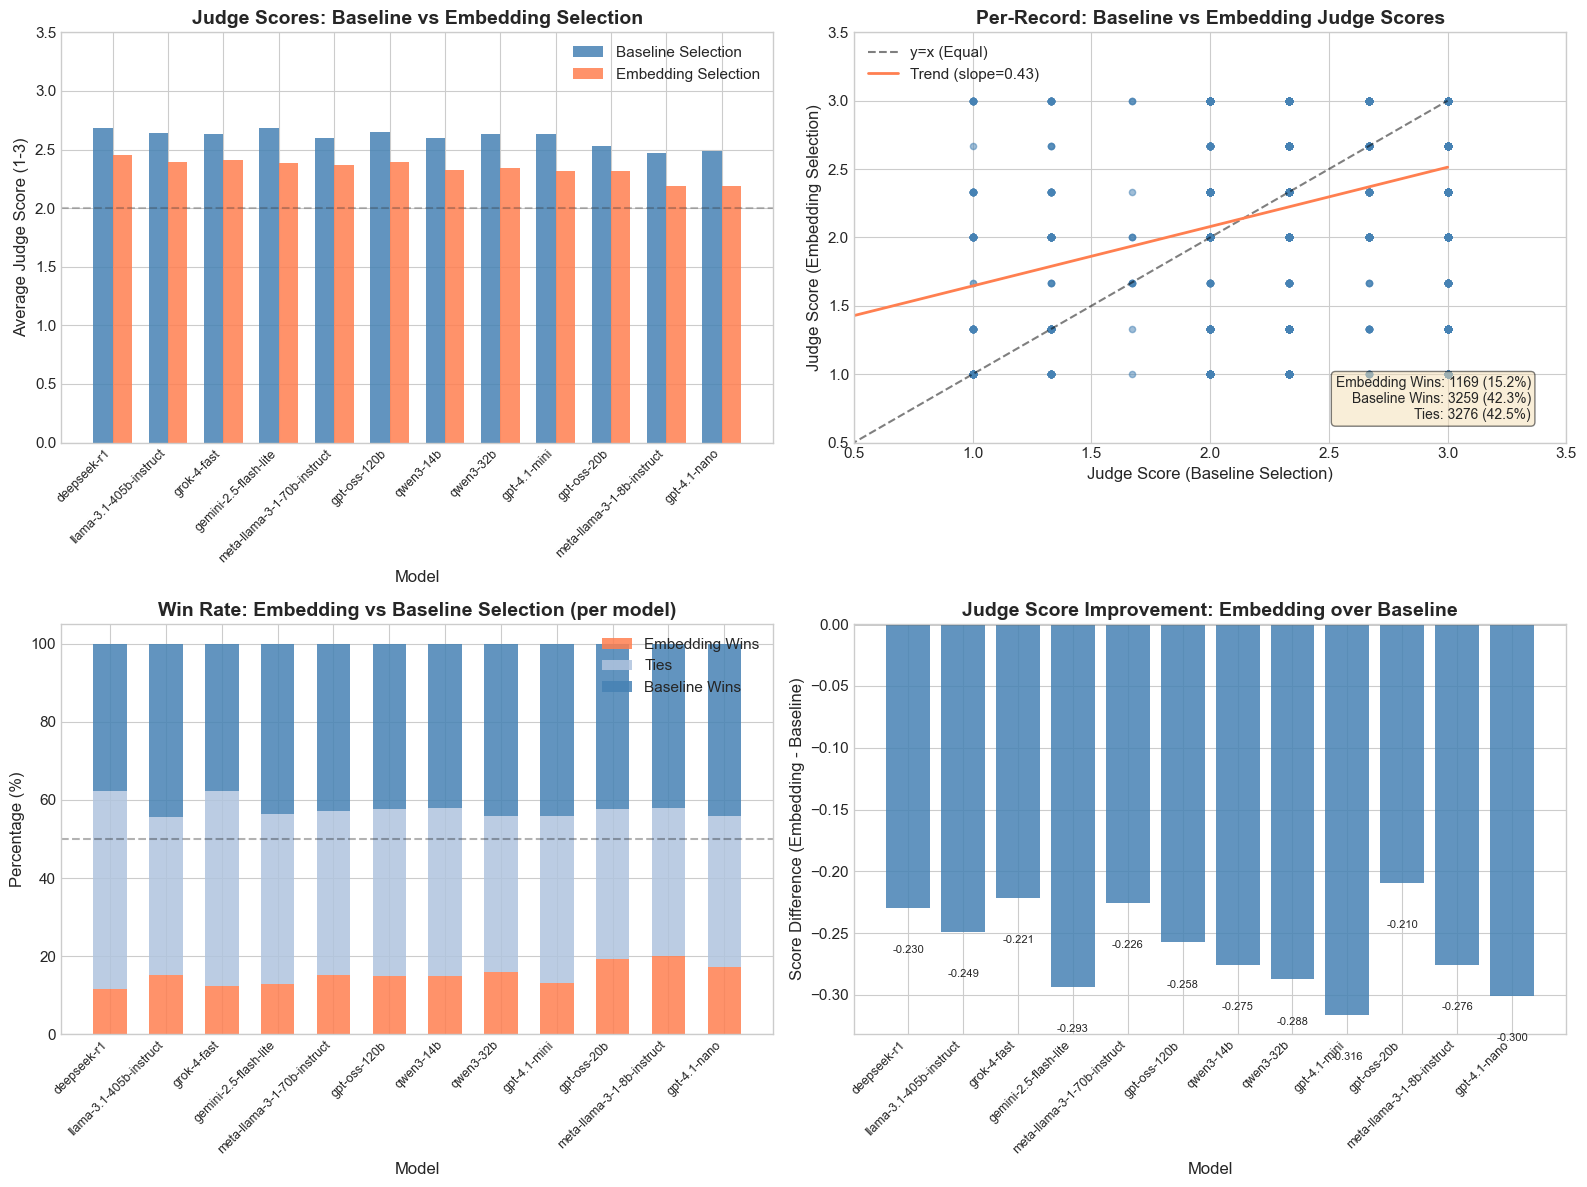


KEY FINDINGS: BASELINE VS EMBEDDING SELECTION

1. OVERALL AVERAGES:
   - Baseline Selection: 2.603
   - Embedding Selection: 2.341
   - Difference: -0.262

2. WIN RATES (overall):
   - Embedding Wins: 110 / 642 (17.1%)
   - Baseline Wins: 283 / 642 (44.1%)
   - Ties: 249 / 642 (38.8%)

3. MODELS BETTER WITH EMBEDDING: 0 / 12


In [14]:
# Cell 4: Baseline vs Embedding Selection Comparison

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =============================================================================
# Plot 1: Side-by-side Judge Score Comparison by Model
# =============================================================================
ax1 = axes[0, 0]
x = np.arange(len(model_order))
width = 0.35

baseline_scores = [model_summary[model_summary['model'] == m]['Judge Avg (Baseline)'].values[0] for m in model_order]
embedding_scores = [model_summary[model_summary['model'] == m]['Judge Avg (Embedding)'].values[0] for m in model_order]

bars1 = ax1.bar(x - width/2, baseline_scores, width, label='Baseline Selection', color=COLORS['primary'], alpha=0.85)
bars2 = ax1.bar(x + width/2, embedding_scores, width, label='Embedding Selection', color=COLORS['secondary'], alpha=0.85)

ax1.set_xlabel('Model')
ax1.set_ylabel('Average Judge Score (1-3)')
ax1.set_title('Judge Scores: Baseline vs Embedding Selection')
ax1.set_xticks(x)
ax1.set_xticklabels(model_order, rotation=45, ha='right', fontsize=9)
ax1.legend(loc='upper right')
ax1.set_ylim(0, 3.5)
ax1.axhline(y=2, color=COLORS['text'], linestyle='--', alpha=0.3)

# =============================================================================
# Plot 2: Scatter Plot - Baseline vs Embedding
# =============================================================================
ax2 = axes[0, 1]

# Get per-record data
valid_mask = df['judge_baseline_avg'].notna() & df['judge_embedding_avg'].notna()
baseline_vals = df.loc[valid_mask, 'judge_baseline_avg']
embedding_vals = df.loc[valid_mask, 'judge_embedding_avg']

ax2.scatter(baseline_vals, embedding_vals, alpha=0.3, s=20, color=COLORS['primary'])
ax2.plot([0, 3], [0, 3], 'k--', alpha=0.5, label='y=x (Equal)')

# Add regression line
z = np.polyfit(baseline_vals, embedding_vals, 1)
p = np.poly1d(z)
ax2.plot([0.5, 3], p([0.5, 3]), color=COLORS['secondary'], linestyle='-', linewidth=2, label=f'Trend (slope={z[0]:.2f})')

ax2.set_xlabel('Judge Score (Baseline Selection)')
ax2.set_ylabel('Judge Score (Embedding Selection)')
ax2.set_title('Per-Record: Baseline vs Embedding Judge Scores')
ax2.legend(loc='upper left')
ax2.set_xlim(0.5, 3.5)
ax2.set_ylim(0.5, 3.5)

# Add annotation for win rate
embedding_wins = (embedding_vals > baseline_vals).sum()
baseline_wins = (baseline_vals > embedding_vals).sum()
ties = (baseline_vals == embedding_vals).sum()
total = len(baseline_vals)

ax2.text(0.95, 0.05, f'Embedding Wins: {embedding_wins} ({embedding_wins/total*100:.1f}%)\n'
                      f'Baseline Wins: {baseline_wins} ({baseline_wins/total*100:.1f}%)\n'
                      f'Ties: {ties} ({ties/total*100:.1f}%)',
         transform=ax2.transAxes, fontsize=10, verticalalignment='bottom',
         horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# =============================================================================
# Plot 3: Win Rate per Model
# =============================================================================
ax3 = axes[1, 0]

win_rates = []
for model in model_order:
    model_df = df[df['model'] == model]
    valid = model_df['judge_baseline_avg'].notna() & model_df['judge_embedding_avg'].notna()
    model_df = model_df[valid]
    
    embedding_wins = (model_df['judge_embedding_avg'] > model_df['judge_baseline_avg']).sum()
    baseline_wins = (model_df['judge_baseline_avg'] > model_df['judge_embedding_avg']).sum()
    ties = (model_df['judge_baseline_avg'] == model_df['judge_embedding_avg']).sum()
    total = len(model_df)
    
    win_rates.append({
        'model': model,
        'embedding_win_rate': embedding_wins / total * 100 if total > 0 else 0,
        'baseline_win_rate': baseline_wins / total * 100 if total > 0 else 0,
        'tie_rate': ties / total * 100 if total > 0 else 0
    })

win_df = pd.DataFrame(win_rates)
win_df = win_df.set_index('model').loc[model_order]

# Stacked bar chart
x = np.arange(len(model_order))
width = 0.6

ax3.bar(x, win_df['embedding_win_rate'], width, label='Embedding Wins', color=COLORS['secondary'], alpha=0.85)
ax3.bar(x, win_df['tie_rate'], width, bottom=win_df['embedding_win_rate'], label='Ties', color=COLORS['light'], alpha=0.85)
ax3.bar(x, win_df['baseline_win_rate'], width, 
        bottom=win_df['embedding_win_rate'] + win_df['tie_rate'], 
        label='Baseline Wins', color=COLORS['primary'], alpha=0.85)

ax3.set_xlabel('Model')
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Win Rate: Embedding vs Baseline Selection (per model)')
ax3.set_xticks(x)
ax3.set_xticklabels(model_order, rotation=45, ha='right', fontsize=9)
ax3.legend(loc='upper right')
ax3.axhline(y=50, color='black', linestyle='--', alpha=0.3)

# =============================================================================
# Plot 4: Delta Analysis (Embedding - Baseline)
# =============================================================================
ax4 = axes[1, 1]

delta_scores = [embedding_scores[i] - baseline_scores[i] for i in range(len(model_order))]
colors = [COLORS['secondary'] if d >= 0 else COLORS['primary'] for d in delta_scores]

bars = ax4.bar(model_order, delta_scores, color=colors, alpha=0.85)
ax4.axhline(y=0, color='black', linewidth=1)
ax4.set_xlabel('Model')
ax4.set_ylabel('Score Difference (Embedding - Baseline)')
ax4.set_title('Judge Score Improvement: Embedding over Baseline')
ax4.set_xticklabels(model_order, rotation=45, ha='right', fontsize=9)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, delta_scores)):
    ypos = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.03
    ax4.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:.3f}', 
             ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_baseline_vs_embedding.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print key findings
print("\n" + "=" * 80)
print("KEY FINDINGS: BASELINE VS EMBEDDING SELECTION")
print("=" * 80)

overall_baseline_avg = df['judge_baseline_avg'].mean()
overall_embedding_avg = df['judge_embedding_avg'].mean()

print(f"\n1. OVERALL AVERAGES:")
print(f"   - Baseline Selection: {overall_baseline_avg:.3f}")
print(f"   - Embedding Selection: {overall_embedding_avg:.3f}")
print(f"   - Difference: {overall_embedding_avg - overall_baseline_avg:.3f}")

print(f"\n2. WIN RATES (overall):")
print(f"   - Embedding Wins: {embedding_wins} / {total} ({embedding_wins/total*100:.1f}%)")
print(f"   - Baseline Wins: {baseline_wins} / {total} ({baseline_wins/total*100:.1f}%)")
print(f"   - Ties: {ties} / {total} ({ties/total*100:.1f}%)")

better_with_embedding = sum(1 for d in delta_scores if d > 0)
print(f"\n3. MODELS BETTER WITH EMBEDDING: {better_with_embedding} / {len(model_order)}")

## Cell 5: Question 3 - Targetonly vs Withsub Mode

Compare the two generation modes:
- **Targetonly**: LLM generates analogies based only on the target concept
- **Withsub**: LLM generates analogies using target + its sub-concepts

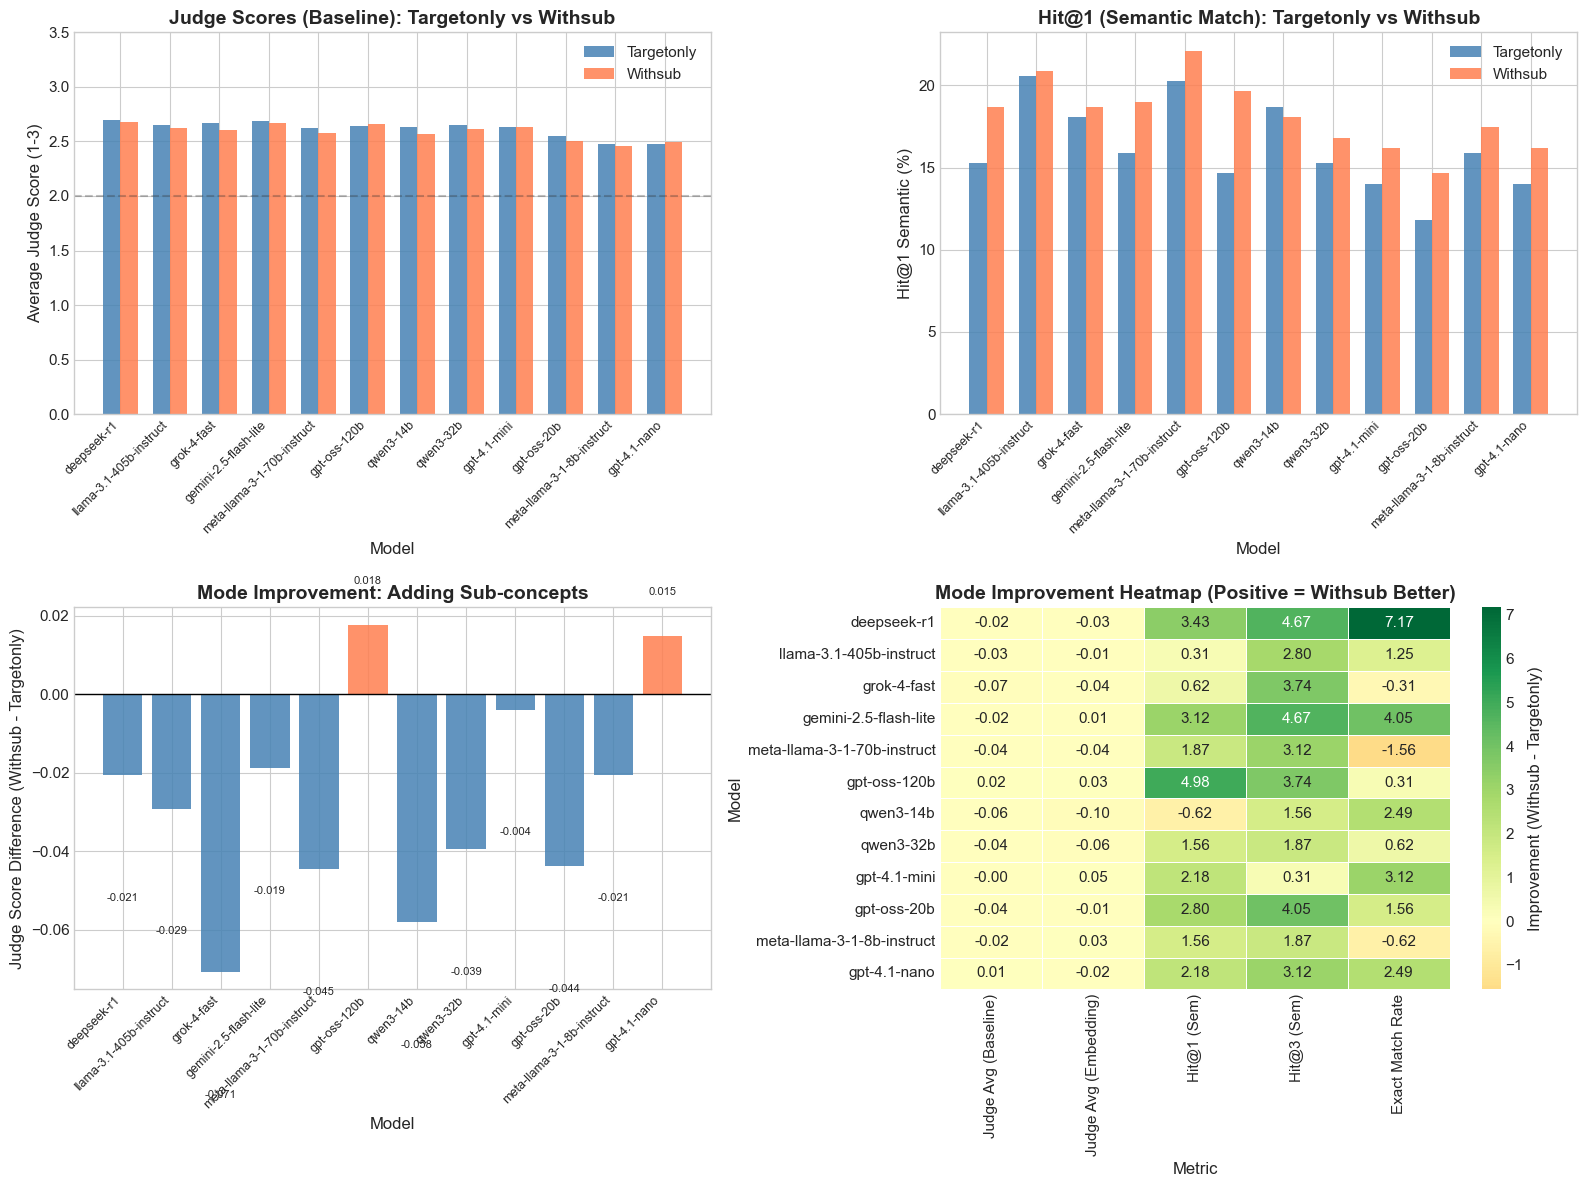


KEY FINDINGS: TARGETONLY VS WITHSUB MODE

1. OVERALL JUDGE SCORES:
   - Targetonly: 2.616
   - Withsub: 2.590
   - Difference: -0.026

2. MODELS BY BETTER MODE:
   - Withsub Better: 2 / 12
   - Targetonly Better: 10 / 12
   - Equal: 0 / 12

3. MODELS MOST BENEFITING FROM SUBCONCEPTS:
   - gpt-oss-120b: +0.018
   - gpt-4.1-nano: +0.015
   - gpt-4.1-mini: +-0.004


In [15]:
# Cell 5: Targetonly vs Withsub Mode Comparison

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare mode-based summary
mode_summary = summary_df.copy()

# =============================================================================
# Plot 1: Grouped Bar Chart - Key Metrics by Mode
# =============================================================================
ax1 = axes[0, 0]

# Get targetonly and withsub values for each model
targetonly_data = mode_summary[mode_summary['mode'] == 'targetonly'].set_index('model')
withsub_data = mode_summary[mode_summary['mode'] == 'withsub'].set_index('model')

x = np.arange(len(model_order))
width = 0.35

# Judge Average (Baseline)
targetonly_judge = [targetonly_data.loc[m, 'Judge Avg (Baseline)'] if m in targetonly_data.index else 0 for m in model_order]
withsub_judge = [withsub_data.loc[m, 'Judge Avg (Baseline)'] if m in withsub_data.index else 0 for m in model_order]

bars1 = ax1.bar(x - width/2, targetonly_judge, width, label='Targetonly', color=COLORS['primary'], alpha=0.85)
bars2 = ax1.bar(x + width/2, withsub_judge, width, label='Withsub', color=COLORS['secondary'], alpha=0.85)

ax1.set_xlabel('Model')
ax1.set_ylabel('Average Judge Score (1-3)')
ax1.set_title('Judge Scores (Baseline): Targetonly vs Withsub')
ax1.set_xticks(x)
ax1.set_xticklabels(model_order, rotation=45, ha='right', fontsize=9)
ax1.legend(loc='upper right')
ax1.set_ylim(0, 3.5)
ax1.axhline(y=2, color=COLORS['text'], linestyle='--', alpha=0.3)

# =============================================================================
# Plot 2: Hit@K Comparison by Mode
# =============================================================================
ax2 = axes[0, 1]

# Hit@1 (Semantic)
targetonly_hit = [targetonly_data.loc[m, 'Hit@1 (Sem)'] if m in targetonly_data.index else 0 for m in model_order]
withsub_hit = [withsub_data.loc[m, 'Hit@1 (Sem)'] if m in withsub_data.index else 0 for m in model_order]

bars1 = ax2.bar(x - width/2, targetonly_hit, width, label='Targetonly', color=COLORS['primary'], alpha=0.85)
bars2 = ax2.bar(x + width/2, withsub_hit, width, label='Withsub', color=COLORS['secondary'], alpha=0.85)

ax2.set_xlabel('Model')
ax2.set_ylabel('Hit@1 Semantic (%)')
ax2.set_title('Hit@1 (Semantic Match): Targetonly vs Withsub')
ax2.set_xticks(x)
ax2.set_xticklabels(model_order, rotation=45, ha='right', fontsize=9)
ax2.legend(loc='upper right')

# =============================================================================
# Plot 3: Delta Analysis (Withsub - Targetonly)
# =============================================================================
ax3 = axes[1, 0]

delta_judge = [withsub_judge[i] - targetonly_judge[i] for i in range(len(model_order))]
colors = [COLORS['secondary'] if d >= 0 else COLORS['primary'] for d in delta_judge]

bars = ax3.bar(model_order, delta_judge, color=colors, alpha=0.85)
ax3.axhline(y=0, color='black', linewidth=1)
ax3.set_xlabel('Model')
ax3.set_ylabel('Judge Score Difference (Withsub - Targetonly)')
ax3.set_title('Mode Improvement: Adding Sub-concepts')
ax3.set_xticklabels(model_order, rotation=45, ha='right', fontsize=9)

# Add value labels
for bar, val in zip(bars, delta_judge):
    ypos = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.03
    ax3.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:.3f}', 
             ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)

# =============================================================================
# Plot 4: Mode Comparison Heatmap
# =============================================================================
ax4 = axes[1, 1]

# Create comparison dataframe
metrics_compare = ['Judge Avg (Baseline)', 'Judge Avg (Embedding)', 'Hit@1 (Sem)', 'Hit@3 (Sem)', 'Exact Match Rate']
comparison_data = []

for model in model_order:
    row = {'model': model}
    for metric in metrics_compare:
        to_val = targetonly_data.loc[model, metric] if model in targetonly_data.index else np.nan
        ws_val = withsub_data.loc[model, metric] if model in withsub_data.index else np.nan
        row[f'{metric} (TO)'] = to_val
        row[f'{metric} (WS)'] = ws_val
        row[f'{metric} (Delta)'] = ws_val - to_val if pd.notna(to_val) and pd.notna(ws_val) else np.nan
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data).set_index('model')

# Plot delta heatmap
delta_cols = [c for c in comparison_df.columns if '(Delta)' in c]
delta_df = comparison_df[delta_cols].copy()
delta_df.columns = [c.replace(' (Delta)', '') for c in delta_cols]

sns.heatmap(delta_df, annot=True, cmap='RdYlGn', center=0, fmt='.2f', 
            linewidths=0.5, ax=ax4, cbar_kws={'label': 'Improvement (Withsub - Targetonly)'})
ax4.set_title('Mode Improvement Heatmap (Positive = Withsub Better)')
ax4.set_xlabel('Metric')
ax4.set_ylabel('Model')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_targetonly_vs_withsub.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print key findings
print("\n" + "=" * 80)
print("KEY FINDINGS: TARGETONLY VS WITHSUB MODE")
print("=" * 80)

# Overall averages by mode
targetonly_overall = df[df['mode'] == 'targetonly']['judge_baseline_avg'].mean()
withsub_overall = df[df['mode'] == 'withsub']['judge_baseline_avg'].mean()

print(f"\n1. OVERALL JUDGE SCORES:")
print(f"   - Targetonly: {targetonly_overall:.3f}")
print(f"   - Withsub: {withsub_overall:.3f}")
print(f"   - Difference: {withsub_overall - targetonly_overall:.3f}")

# Count which mode is better per model
withsub_better = sum(1 for d in delta_judge if d > 0)
targetonly_better = sum(1 for d in delta_judge if d < 0)
equal = sum(1 for d in delta_judge if d == 0)

print(f"\n2. MODELS BY BETTER MODE:")
print(f"   - Withsub Better: {withsub_better} / {len(model_order)}")
print(f"   - Targetonly Better: {targetonly_better} / {len(model_order)}")
print(f"   - Equal: {equal} / {len(model_order)}")

# Top beneficiaries of subconcepts
sorted_delta = sorted(zip(model_order, delta_judge), key=lambda x: x[1], reverse=True)
print(f"\n3. MODELS MOST BENEFITING FROM SUBCONCEPTS:")
for model, delta in sorted_delta[:3]:
    print(f"   - {model}: +{delta:.3f}")

## Cell 6: Model Consistency Analysis

Analyze how consistent each model's performance is across different targets. Lower variance indicates more reliable performance.

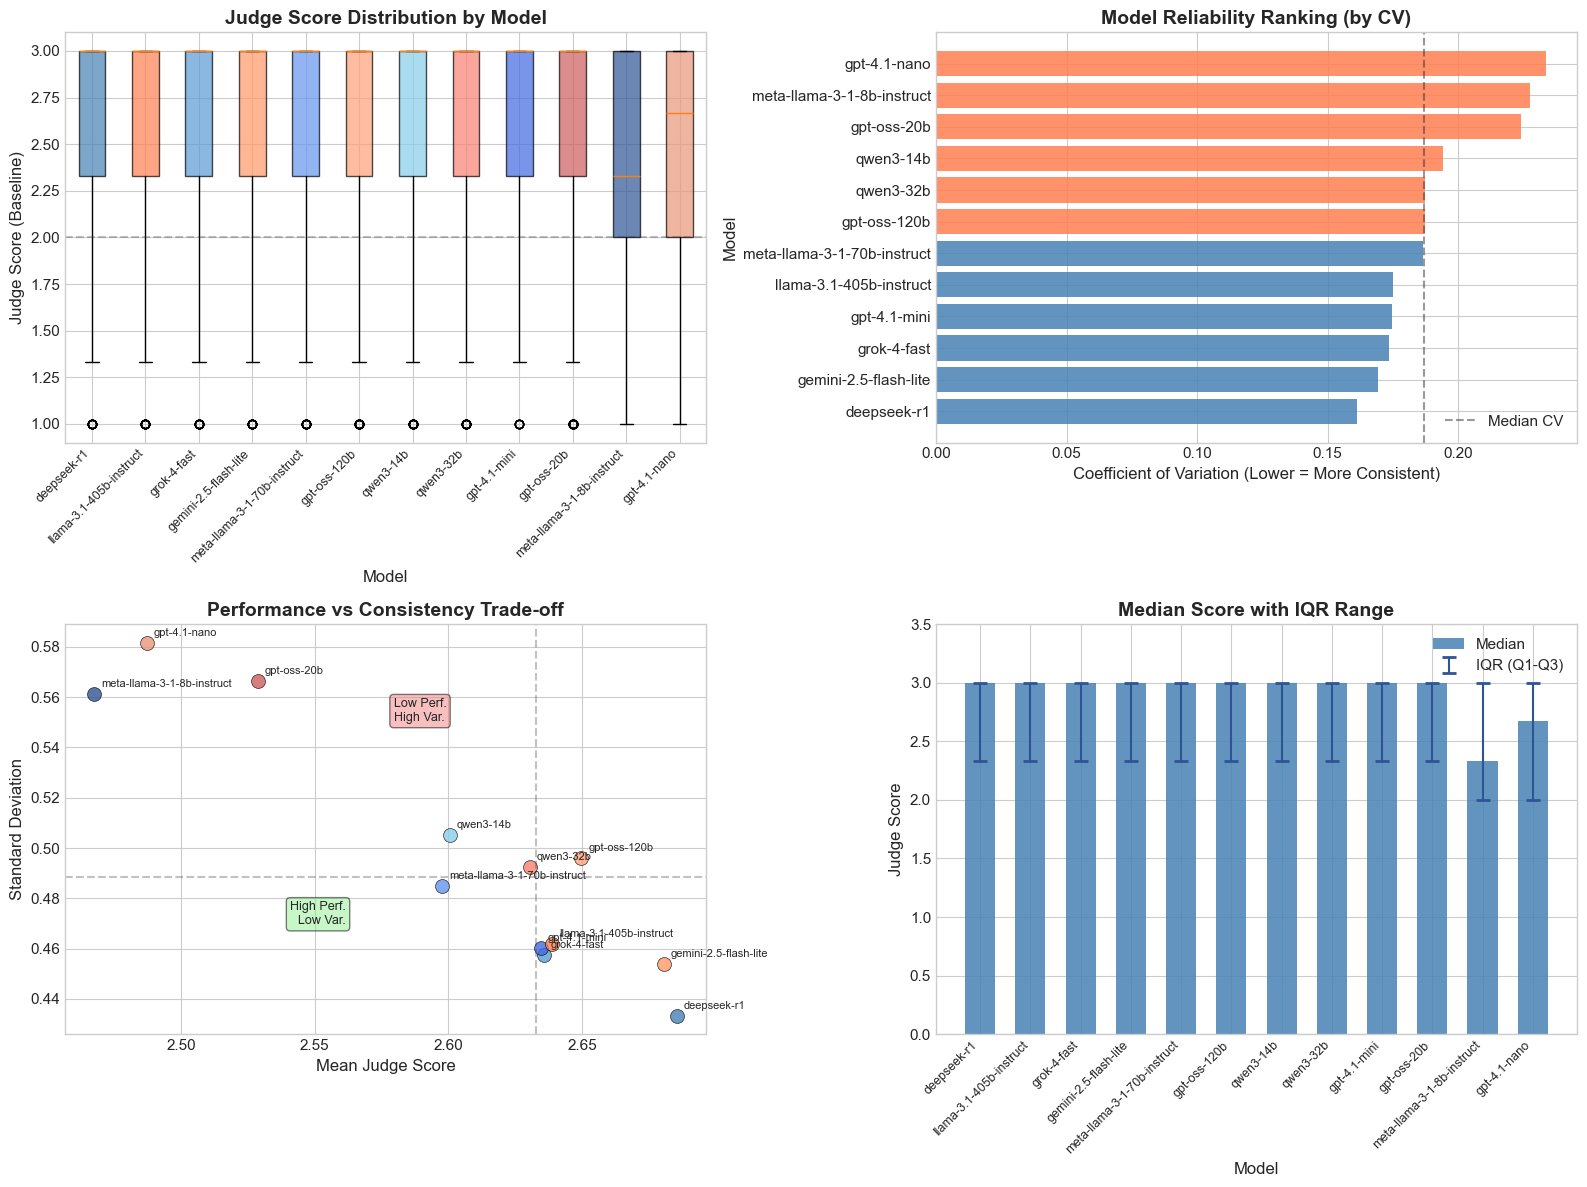


KEY FINDINGS: MODEL CONSISTENCY

1. MOST CONSISTENT MODELS (Lowest CV):
   1. deepseek-r1: CV=0.161, Mean=2.686, Std=0.433
   2. gemini-2.5-flash-lite: CV=0.169, Mean=2.681, Std=0.454
   3. grok-4-fast: CV=0.174, Mean=2.636, Std=0.457

2. LEAST CONSISTENT MODELS (Highest CV):
   1. gpt-4.1-nano: CV=0.234, Mean=2.487, Std=0.582
   2. meta-llama-3-1-8b-instruct: CV=0.227, Mean=2.468, Std=0.561
   3. gpt-oss-20b: CV=0.224, Mean=2.529, Std=0.566

3. BEST TRADE-OFF (High Performance + Consistency):
   deepseek-r1: Mean=2.686, Std=0.433


In [16]:
# Cell 6: Model Consistency Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =============================================================================
# Plot 1: Box Plots - Judge Score Distribution per Model
# =============================================================================
ax1 = axes[0, 0]

# Prepare data for box plot
box_data = []
box_labels = []
for model in model_order:
    model_df = df[df['model'] == model]
    scores = model_df['judge_baseline_avg'].dropna()
    box_data.append(scores)
    box_labels.append(model)

bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True)

# Color boxes alternating steel blue and coral
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(PALETTE_MAIN[i % len(PALETTE_MAIN)])
    patch.set_alpha(0.7)

ax1.set_xlabel('Model')
ax1.set_ylabel('Judge Score (Baseline)')
ax1.set_title('Judge Score Distribution by Model')
ax1.set_xticklabels(model_order, rotation=45, ha='right', fontsize=9)
ax1.axhline(y=2, color=COLORS['text'], linestyle='--', alpha=0.3)

# =============================================================================
# Plot 2: Coefficient of Variation (CV) - Reliability Ranking
# =============================================================================
ax2 = axes[0, 1]

# Compute CV (std/mean) for each model
cv_data = []
for model in model_order:
    model_df = df[df['model'] == model]
    scores = model_df['judge_baseline_avg'].dropna()
    mean_score = scores.mean()
    std_score = scores.std()
    cv = std_score / mean_score if mean_score > 0 else np.nan
    cv_data.append({
        'model': model,
        'mean': mean_score,
        'std': std_score,
        'cv': cv
    })

cv_df = pd.DataFrame(cv_data)
cv_df = cv_df.sort_values('cv')  # Lower CV = more consistent

# Bar chart
colors = [COLORS['primary'] if cv < cv_df['cv'].median() else COLORS['secondary'] for cv in cv_df['cv']]
bars = ax2.barh(cv_df['model'], cv_df['cv'], color=colors, alpha=0.85)

ax2.set_xlabel('Coefficient of Variation (Lower = More Consistent)')
ax2.set_ylabel('Model')
ax2.set_title('Model Reliability Ranking (by CV)')
ax2.axvline(x=cv_df['cv'].median(), color=COLORS['text'], linestyle='--', alpha=0.5, label='Median CV')
ax2.legend()

# =============================================================================
# Plot 3: Mean vs Standard Deviation Scatter
# =============================================================================
ax3 = axes[1, 0]

for i, row in cv_df.iterrows():
    ax3.scatter(row['mean'], row['std'], s=100, color=PALETTE_MAIN[model_order.index(row['model']) % len(PALETTE_MAIN)], 
                alpha=0.8, edgecolors='black', linewidth=0.5)
    ax3.annotate(row['model'], (row['mean'], row['std']), fontsize=8, 
                 xytext=(5, 5), textcoords='offset points')

ax3.set_xlabel('Mean Judge Score')
ax3.set_ylabel('Standard Deviation')
ax3.set_title('Performance vs Consistency Trade-off')

# Add quadrant lines
ax3.axvline(x=cv_df['mean'].median(), color=COLORS['text'], linestyle='--', alpha=0.3)
ax3.axhline(y=cv_df['std'].median(), color=COLORS['text'], linestyle='--', alpha=0.3)

# Add quadrant labels
xlim = ax3.get_xlim()
ylim = ax3.get_ylim()
ax3.text(xlim[1] * 0.95, ylim[0] * 1.1, 'High Perf.\nLow Var.', fontsize=9, ha='right', va='bottom',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax3.text(xlim[0] * 1.05, ylim[1] * 0.95, 'Low Perf.\nHigh Var.', fontsize=9, ha='left', va='top',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

# =============================================================================
# Plot 4: Interquartile Range Analysis
# =============================================================================
ax4 = axes[1, 1]

# Compute IQR for each model
iqr_data = []
for model in model_order:
    model_df = df[df['model'] == model]
    scores = model_df['judge_baseline_avg'].dropna()
    q1 = scores.quantile(0.25)
    q3 = scores.quantile(0.75)
    iqr = q3 - q1
    iqr_data.append({
        'model': model,
        'q1': q1,
        'median': scores.median(),
        'q3': q3,
        'iqr': iqr
    })

iqr_df = pd.DataFrame(iqr_data)

x = np.arange(len(model_order))
width = 0.6

# Plot Q1-Q3 range as error bars
ax4.bar(x, iqr_df['median'], width, color=COLORS['primary'], alpha=0.85, label='Median')
ax4.errorbar(x, iqr_df['median'], yerr=[iqr_df['median'] - iqr_df['q1'], iqr_df['q3'] - iqr_df['median']], 
             fmt='none', color=COLORS['dark'], capsize=5, capthick=2, label='IQR (Q1-Q3)')

ax4.set_xlabel('Model')
ax4.set_ylabel('Judge Score')
ax4.set_title('Median Score with IQR Range')
ax4.set_xticks(x)
ax4.set_xticklabels(model_order, rotation=45, ha='right', fontsize=9)
ax4.legend(loc='upper right')
ax4.set_ylim(0, 3.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_model_consistency.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print key findings
print("\n" + "=" * 80)
print("KEY FINDINGS: MODEL CONSISTENCY")
print("=" * 80)

cv_df_sorted = cv_df.sort_values('cv')
print(f"\n1. MOST CONSISTENT MODELS (Lowest CV):")
for i, (_, row) in enumerate(cv_df_sorted.head(3).iterrows()):
    print(f"   {i+1}. {row['model']}: CV={row['cv']:.3f}, Mean={row['mean']:.3f}, Std={row['std']:.3f}")

print(f"\n2. LEAST CONSISTENT MODELS (Highest CV):")
for i, (_, row) in enumerate(cv_df_sorted.tail(3).iloc[::-1].iterrows()):
    print(f"   {i+1}. {row['model']}: CV={row['cv']:.3f}, Mean={row['mean']:.3f}, Std={row['std']:.3f}")

# Find best trade-off (high mean, low std)
cv_df['trade_off_score'] = cv_df['mean'] - cv_df['std']
best_trade_off = cv_df.loc[cv_df['trade_off_score'].idxmax()]
print(f"\n3. BEST TRADE-OFF (High Performance + Consistency):")
print(f"   {best_trade_off['model']}: Mean={best_trade_off['mean']:.3f}, Std={best_trade_off['std']:.3f}")

## Cell 7: Target Difficulty Analysis

Analyze which target concepts are easiest/hardest for models to generate good analogies for.

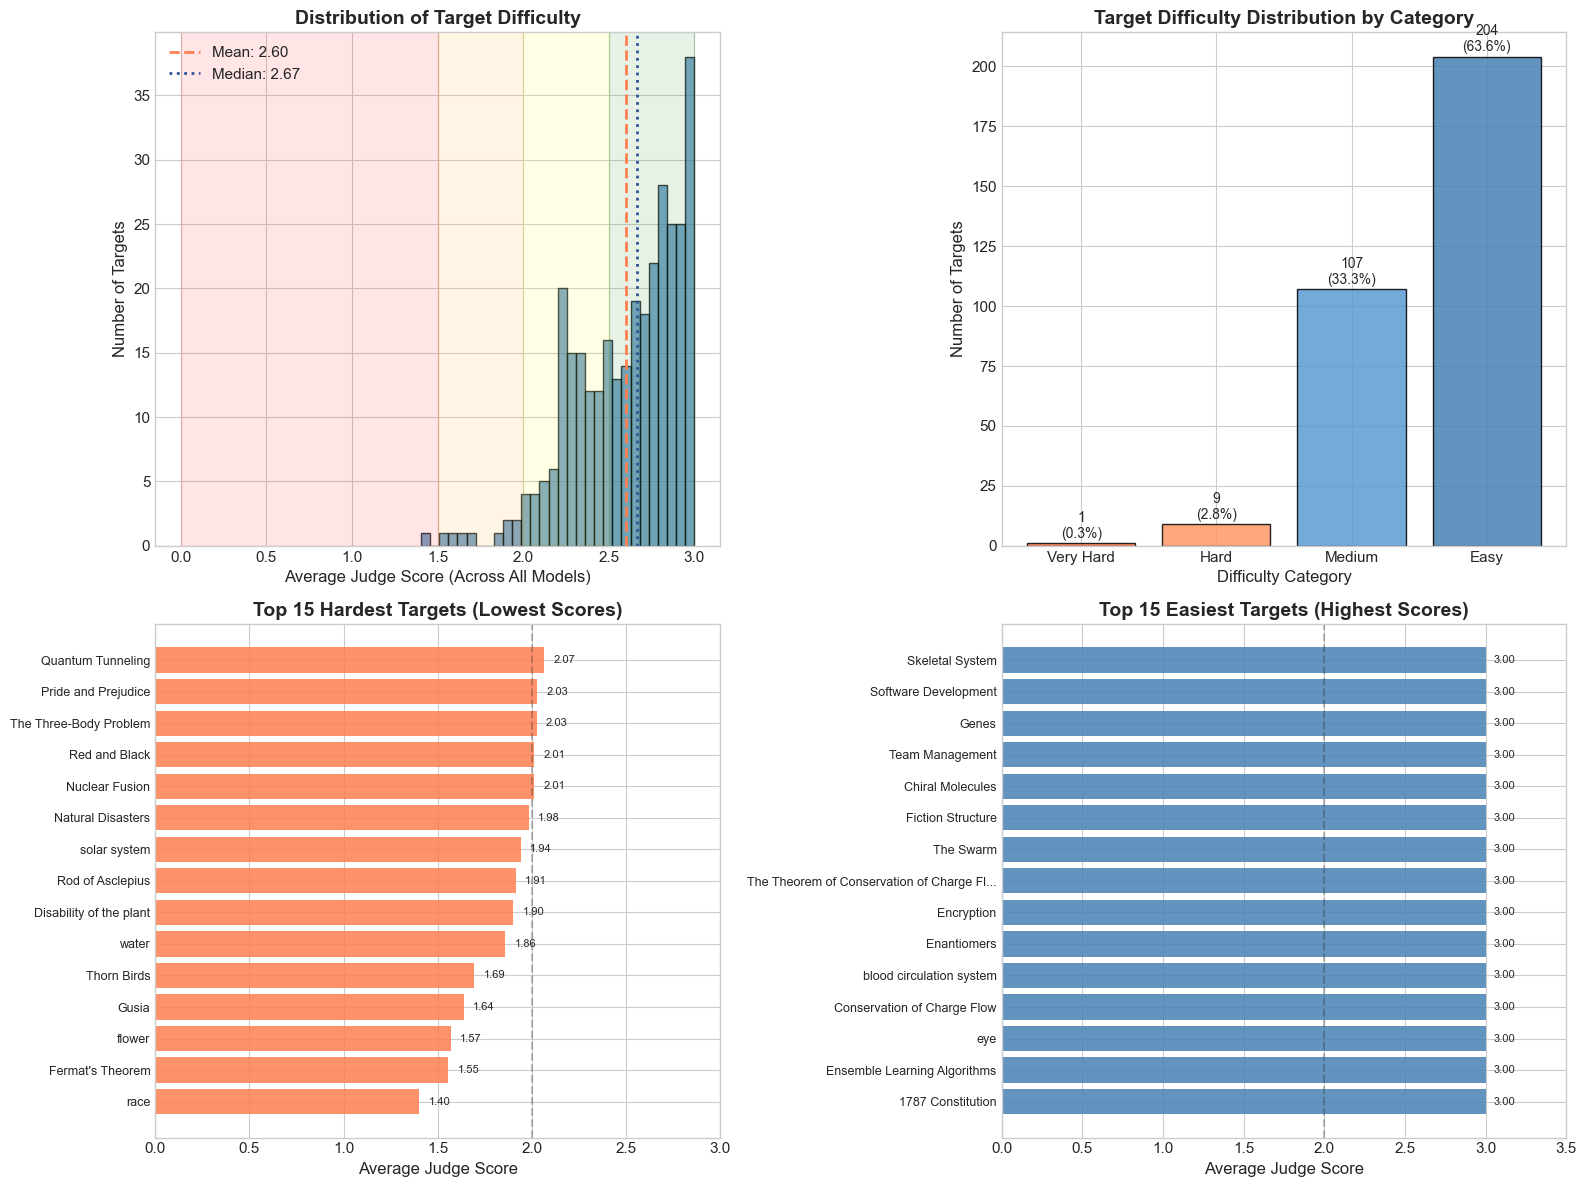


KEY FINDINGS: TARGET DIFFICULTY

1. OVERALL STATISTICS:
   - Total Targets: 321
   - Mean Difficulty Score: 2.603
   - Std: 0.312

2. DIFFICULTY DISTRIBUTION:
   - Very Hard: 1 targets (0.3%)
   - Hard: 9 targets (2.8%)
   - Medium: 107 targets (33.3%)
   - Easy: 204 targets (63.6%)

3. TOP 5 HARDEST TARGETS:
   1. 'race': avg=1.402
   2. 'Fermat's Theorem': avg=1.555
   3. 'flower': avg=1.568
   4. 'Gusia': avg=1.638
   5. 'Thorn Birds': avg=1.693

4. TOP 5 EASIEST TARGETS:
   1. '1787 Constitution': avg=3.000
   2. 'Ensemble Learning Algorithms': avg=3.000
   3. 'eye': avg=3.000
   4. 'Conservation of Charge Flow': avg=3.000
   5. 'blood circulation system': avg=3.000


In [17]:
# Cell 7: Target Difficulty Analysis

# Compute average performance per target (across all models and modes)
target_stats = df.groupby('target').agg({
    'judge_baseline_avg': ['mean', 'std', 'count'],
    'best_exact_rank': lambda x: (x >= 1).sum() / len(x) * 100,  # Exact match rate
    'best_sem_rank': lambda x: (x >= 1).sum() / len(x) * 100,     # Semantic match rate
}).reset_index()

target_stats.columns = ['target', 'avg_judge', 'std_judge', 'n_records', 'exact_match_rate', 'sem_match_rate']
target_stats = target_stats.sort_values('avg_judge')

# Define difficulty levels
target_stats['difficulty'] = pd.cut(target_stats['avg_judge'], 
                                     bins=[0, 1.5, 2.0, 2.5, 3.0], 
                                     labels=['Very Hard', 'Hard', 'Medium', 'Easy'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =============================================================================
# Plot 1: Distribution of Target Difficulties
# =============================================================================
ax1 = axes[0, 0]

ax1.hist(target_stats['avg_judge'], bins=30, color=COLORS['primary'], alpha=0.7, edgecolor='black')
ax1.axvline(x=target_stats['avg_judge'].mean(), color=COLORS['secondary'], linestyle='--', linewidth=2, 
            label=f'Mean: {target_stats["avg_judge"].mean():.2f}')
ax1.axvline(x=target_stats['avg_judge'].median(), color=COLORS['dark'], linestyle=':', linewidth=2, 
            label=f'Median: {target_stats["avg_judge"].median():.2f}')

ax1.set_xlabel('Average Judge Score (Across All Models)')
ax1.set_ylabel('Number of Targets')
ax1.set_title('Distribution of Target Difficulty')
ax1.legend()

# Add difficulty zones
for zone, color, alpha in [((0, 1.5), 'red', 0.1), ((1.5, 2.0), 'orange', 0.1), 
                            ((2.0, 2.5), 'yellow', 0.1), ((2.5, 3.0), 'green', 0.1)]:
    ax1.axvspan(zone[0], zone[1], alpha=alpha, color=color)

# =============================================================================
# Plot 2: Difficulty Category Distribution
# =============================================================================
ax2 = axes[0, 1]

difficulty_counts = target_stats['difficulty'].value_counts().reindex(['Very Hard', 'Hard', 'Medium', 'Easy'])
colors_diff = [COLORS['secondary'], COLORS['accent2'], COLORS['accent1'], COLORS['primary']]

bars = ax2.bar(difficulty_counts.index, difficulty_counts.values, color=colors_diff, alpha=0.85, edgecolor='black')

# Add percentage labels
total = difficulty_counts.sum()
for bar, count in zip(bars, difficulty_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{count}\n({count/total*100:.1f}%)', ha='center', va='bottom', fontsize=10)

ax2.set_xlabel('Difficulty Category')
ax2.set_ylabel('Number of Targets')
ax2.set_title('Target Difficulty Distribution by Category')

# =============================================================================
# Plot 3: Top 15 Hardest Targets
# =============================================================================
ax3 = axes[1, 0]

hardest = target_stats.head(15)
y_pos = np.arange(len(hardest))

bars = ax3.barh(y_pos, hardest['avg_judge'], color=COLORS['secondary'], alpha=0.85)
ax3.set_yticks(y_pos)
ax3.set_yticklabels([t[:40] + '...' if len(t) > 40 else t for t in hardest['target']], fontsize=9)
ax3.set_xlabel('Average Judge Score')
ax3.set_title('Top 15 Hardest Targets (Lowest Scores)')
ax3.axvline(x=2, color=COLORS['text'], linestyle='--', alpha=0.3)
ax3.set_xlim(0, 3)

# Add score labels
for bar, score in zip(bars, hardest['avg_judge']):
    ax3.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
             f'{score:.2f}', va='center', fontsize=8)

# =============================================================================
# Plot 4: Top 15 Easiest Targets
# =============================================================================
ax4 = axes[1, 1]

easiest = target_stats.tail(15).iloc[::-1]
y_pos = np.arange(len(easiest))

bars = ax4.barh(y_pos, easiest['avg_judge'], color=COLORS['primary'], alpha=0.85)
ax4.set_yticks(y_pos)
ax4.set_yticklabels([t[:40] + '...' if len(t) > 40 else t for t in easiest['target']], fontsize=9)
ax4.set_xlabel('Average Judge Score')
ax4.set_title('Top 15 Easiest Targets (Highest Scores)')
ax4.axvline(x=2, color=COLORS['text'], linestyle='--', alpha=0.3)
ax4.set_xlim(0, 3.5)

# Add score labels
for bar, score in zip(bars, easiest['avg_judge']):
    ax4.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
             f'{score:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig5_target_difficulty.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print key findings
print("\n" + "=" * 80)
print("KEY FINDINGS: TARGET DIFFICULTY")
print("=" * 80)

print(f"\n1. OVERALL STATISTICS:")
print(f"   - Total Targets: {len(target_stats)}")
print(f"   - Mean Difficulty Score: {target_stats['avg_judge'].mean():.3f}")
print(f"   - Std: {target_stats['avg_judge'].std():.3f}")

print(f"\n2. DIFFICULTY DISTRIBUTION:")
for cat in ['Very Hard', 'Hard', 'Medium', 'Easy']:
    count = difficulty_counts.get(cat, 0)
    print(f"   - {cat}: {count} targets ({count/total*100:.1f}%)")

print(f"\n3. TOP 5 HARDEST TARGETS:")
for i, (_, row) in enumerate(target_stats.head(5).iterrows()):
    print(f"   {i+1}. '{row['target'][:50]}': avg={row['avg_judge']:.3f}")

print(f"\n4. TOP 5 EASIEST TARGETS:")
for i, (_, row) in enumerate(target_stats.tail(5).iloc[::-1].iterrows()):
    print(f"   {i+1}. '{row['target'][:50]}': avg={row['avg_judge']:.3f}")

## Cell 8: Failure Analysis

Analyze failure patterns - when models fail to find gold matches or produce low-quality analogies.

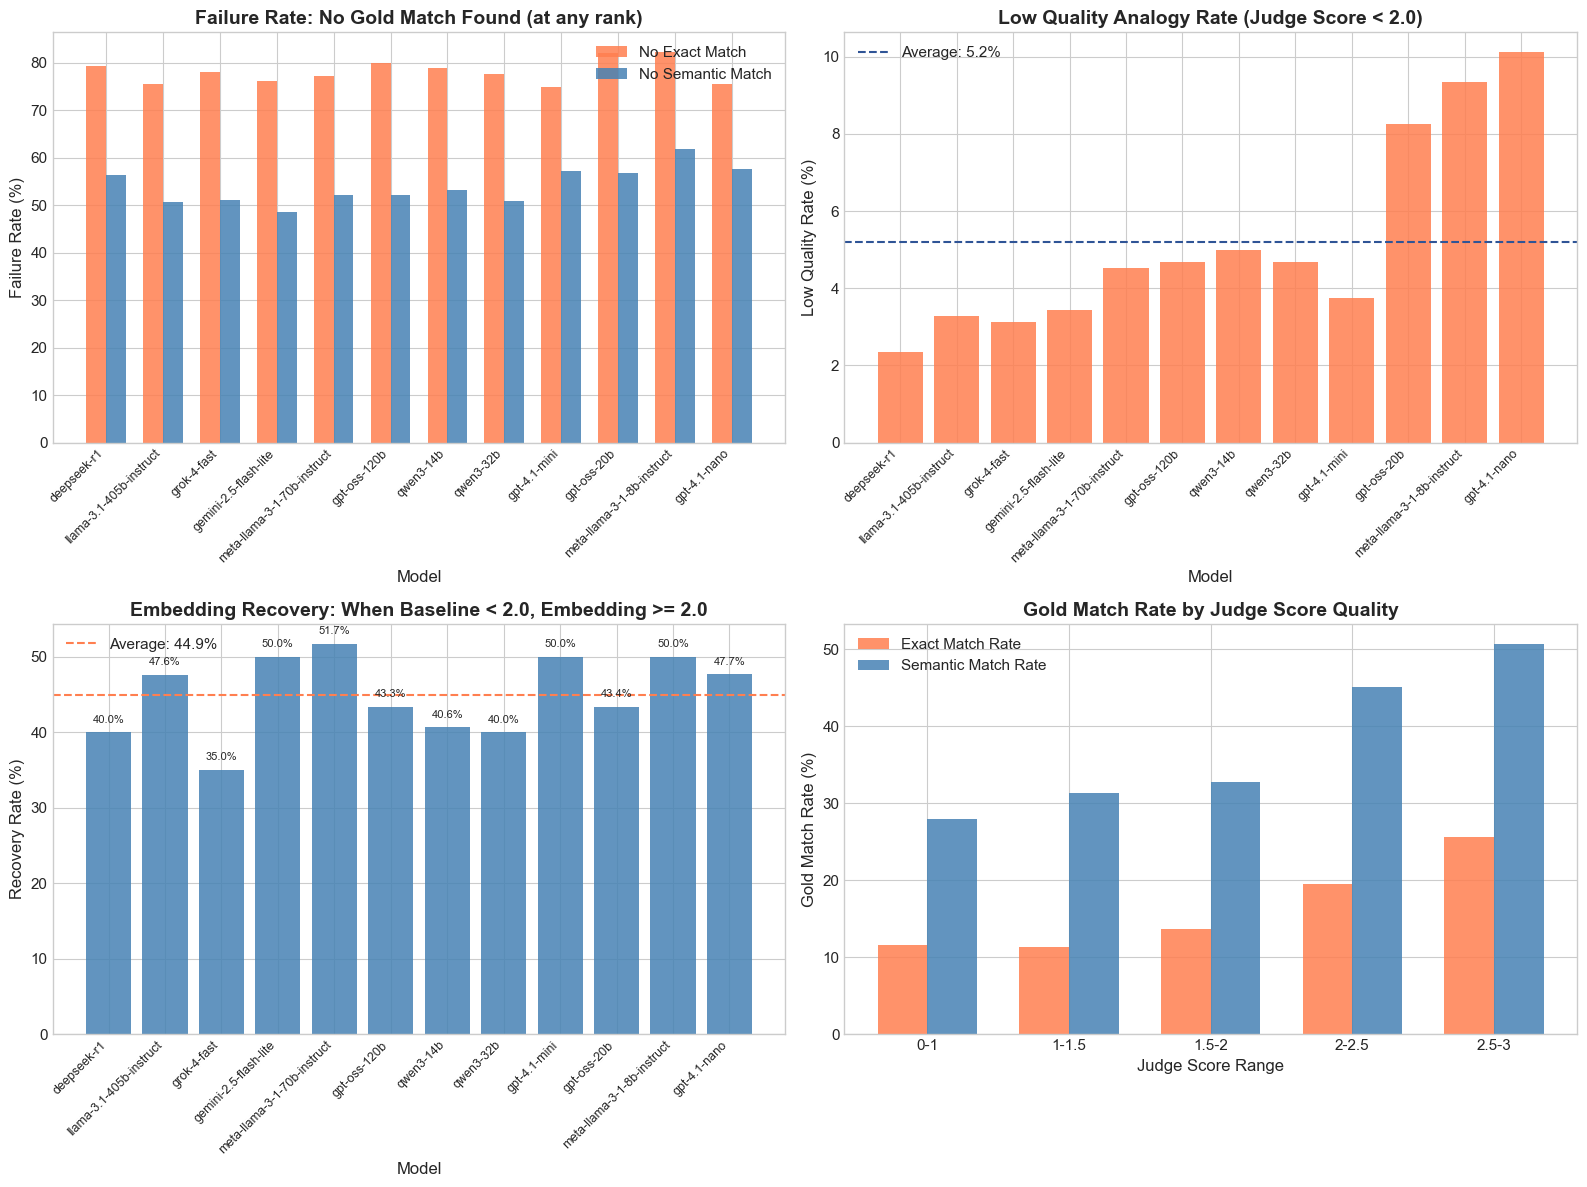


KEY FINDINGS: FAILURE ANALYSIS

1. OVERALL FAILURE RATES:
   - No Exact Match: 78.1%
   - No Semantic Match: 54.0%

2. MODELS WITH LOWEST SEMANTIC FAILURE RATE:
   1. gemini-2.5-flash-lite: 48.4%
   2. llama-3.1-405b-instruct: 50.6%
   3. qwen3-32b: 50.8%

3. LOW QUALITY RATE (Judge < 2.0): 5.2%

4. EMBEDDING RECOVERY:
   - Total baseline low: 401
   - Recovered by embedding: 183 (45.6%)


In [18]:
# Cell 8: Failure Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =============================================================================
# Plot 1: Failure Rate by Model (No Gold Match Found)
# =============================================================================
ax1 = axes[0, 0]

failure_rates = []
for model in model_order:
    model_df = df[df['model'] == model]
    n = len(model_df)
    exact_fail = (model_df['best_exact_rank'] == -1).sum() / n * 100
    sem_fail = (model_df['best_sem_rank'] == -1).sum() / n * 100
    failure_rates.append({
        'model': model,
        'exact_fail_rate': exact_fail,
        'sem_fail_rate': sem_fail
    })

fail_df = pd.DataFrame(failure_rates)

x = np.arange(len(model_order))
width = 0.35

bars1 = ax1.bar(x - width/2, fail_df['exact_fail_rate'], width, label='No Exact Match', color=COLORS['secondary'], alpha=0.85)
bars2 = ax1.bar(x + width/2, fail_df['sem_fail_rate'], width, label='No Semantic Match', color=COLORS['primary'], alpha=0.85)

ax1.set_xlabel('Model')
ax1.set_ylabel('Failure Rate (%)')
ax1.set_title('Failure Rate: No Gold Match Found (at any rank)')
ax1.set_xticks(x)
ax1.set_xticklabels(model_order, rotation=45, ha='right', fontsize=9)
ax1.legend(loc='upper right')

# =============================================================================
# Plot 2: Low Quality Rate by Model (Judge < 2.0)
# =============================================================================
ax2 = axes[0, 1]

low_quality_rates = []
for model in model_order:
    model_df = df[df['model'] == model]
    valid = model_df['judge_baseline_avg'].notna()
    n_valid = valid.sum()
    low_quality = (model_df.loc[valid, 'judge_baseline_avg'] < 2.0).sum()
    low_quality_rates.append({
        'model': model,
        'low_quality_rate': low_quality / n_valid * 100 if n_valid > 0 else 0,
        'n_valid': n_valid
    })

lq_df = pd.DataFrame(low_quality_rates)

bars = ax2.bar(model_order, lq_df['low_quality_rate'], color=COLORS['secondary'], alpha=0.85)
ax2.axhline(y=lq_df['low_quality_rate'].mean(), color=COLORS['dark'], linestyle='--', 
            label=f'Average: {lq_df["low_quality_rate"].mean():.1f}%')

ax2.set_xlabel('Model')
ax2.set_ylabel('Low Quality Rate (%)')
ax2.set_title('Low Quality Analogy Rate (Judge Score < 2.0)')
ax2.set_xticklabels(model_order, rotation=45, ha='right', fontsize=9)
ax2.legend()

# =============================================================================
# Plot 3: Recovery Analysis - When Baseline Fails, Does Embedding Help?
# =============================================================================
ax3 = axes[1, 0]

# Find records where baseline judge < embedding judge
recovery_data = []
for model in model_order:
    model_df = df[df['model'] == model]
    valid = model_df['judge_baseline_avg'].notna() & model_df['judge_embedding_avg'].notna()
    model_df = model_df[valid]
    
    # Cases where baseline is low (< 2.0)
    baseline_low = model_df['judge_baseline_avg'] < 2.0
    
    # Among those, how many have embedding >= 2.0 (recovery)
    recovered = (model_df.loc[baseline_low, 'judge_embedding_avg'] >= 2.0).sum()
    total_low = baseline_low.sum()
    
    recovery_rate = recovered / total_low * 100 if total_low > 0 else 0
    
    recovery_data.append({
        'model': model,
        'recovery_rate': recovery_rate,
        'total_low': total_low,
        'recovered': recovered
    })

recovery_df = pd.DataFrame(recovery_data)

bars = ax3.bar(model_order, recovery_df['recovery_rate'], color=COLORS['primary'], alpha=0.85)
ax3.axhline(y=recovery_df['recovery_rate'].mean(), color=COLORS['secondary'], linestyle='--', 
            label=f'Average: {recovery_df["recovery_rate"].mean():.1f}%')

ax3.set_xlabel('Model')
ax3.set_ylabel('Recovery Rate (%)')
ax3.set_title('Embedding Recovery: When Baseline < 2.0, Embedding >= 2.0')
ax3.set_xticklabels(model_order, rotation=45, ha='right', fontsize=9)
ax3.legend()

# Add value labels
for bar, val in zip(bars, recovery_df['recovery_rate']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

# =============================================================================
# Plot 4: Correlation - Judge Score vs Gold Match Success
# =============================================================================
ax4 = axes[1, 1]

# Group by judge score bins and compute gold match rate
df_valid = df[df['judge_baseline_avg'].notna()].copy()
df_valid['judge_bin'] = pd.cut(df_valid['judge_baseline_avg'], 
                                bins=[0, 1, 1.5, 2, 2.5, 3], 
                                labels=['0-1', '1-1.5', '1.5-2', '2-2.5', '2.5-3'])

gold_by_judge = df_valid.groupby('judge_bin').agg({
    'exact_match_found': 'mean',
    'sem_match_found': 'mean'
}).reset_index()

gold_by_judge['exact_match_found'] *= 100
gold_by_judge['sem_match_found'] *= 100

x = np.arange(len(gold_by_judge))
width = 0.35

bars1 = ax4.bar(x - width/2, gold_by_judge['exact_match_found'], width, 
                label='Exact Match Rate', color=COLORS['secondary'], alpha=0.85)
bars2 = ax4.bar(x + width/2, gold_by_judge['sem_match_found'], width, 
                label='Semantic Match Rate', color=COLORS['primary'], alpha=0.85)

ax4.set_xlabel('Judge Score Range')
ax4.set_ylabel('Gold Match Rate (%)')
ax4.set_title('Gold Match Rate by Judge Score Quality')
ax4.set_xticks(x)
ax4.set_xticklabels(gold_by_judge['judge_bin'])
ax4.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig6_failure_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print key findings
print("\n" + "=" * 80)
print("KEY FINDINGS: FAILURE ANALYSIS")
print("=" * 80)

# Overall failure rates
overall_exact_fail = (df['best_exact_rank'] == -1).mean() * 100
overall_sem_fail = (df['best_sem_rank'] == -1).mean() * 100

print(f"\n1. OVERALL FAILURE RATES:")
print(f"   - No Exact Match: {overall_exact_fail:.1f}%")
print(f"   - No Semantic Match: {overall_sem_fail:.1f}%")

# Models with lowest failure
fail_df_sorted = fail_df.sort_values('sem_fail_rate')
print(f"\n2. MODELS WITH LOWEST SEMANTIC FAILURE RATE:")
for i, (_, row) in enumerate(fail_df_sorted.head(3).iterrows()):
    print(f"   {i+1}. {row['model']}: {row['sem_fail_rate']:.1f}%")

# Overall low quality rate
overall_lq = (df['judge_baseline_avg'] < 2.0).sum() / df['judge_baseline_avg'].notna().sum() * 100
print(f"\n3. LOW QUALITY RATE (Judge < 2.0): {overall_lq:.1f}%")

# Recovery statistics
total_recovered = recovery_df['recovered'].sum()
total_baseline_low = recovery_df['total_low'].sum()
overall_recovery = total_recovered / total_baseline_low * 100 if total_baseline_low > 0 else 0
print(f"\n4. EMBEDDING RECOVERY:")
print(f"   - Total baseline low: {total_baseline_low}")
print(f"   - Recovered by embedding: {total_recovered} ({overall_recovery:.1f}%)")

## Cell 9: Summary Dashboard

Master comparison table with all metrics and key findings summary.

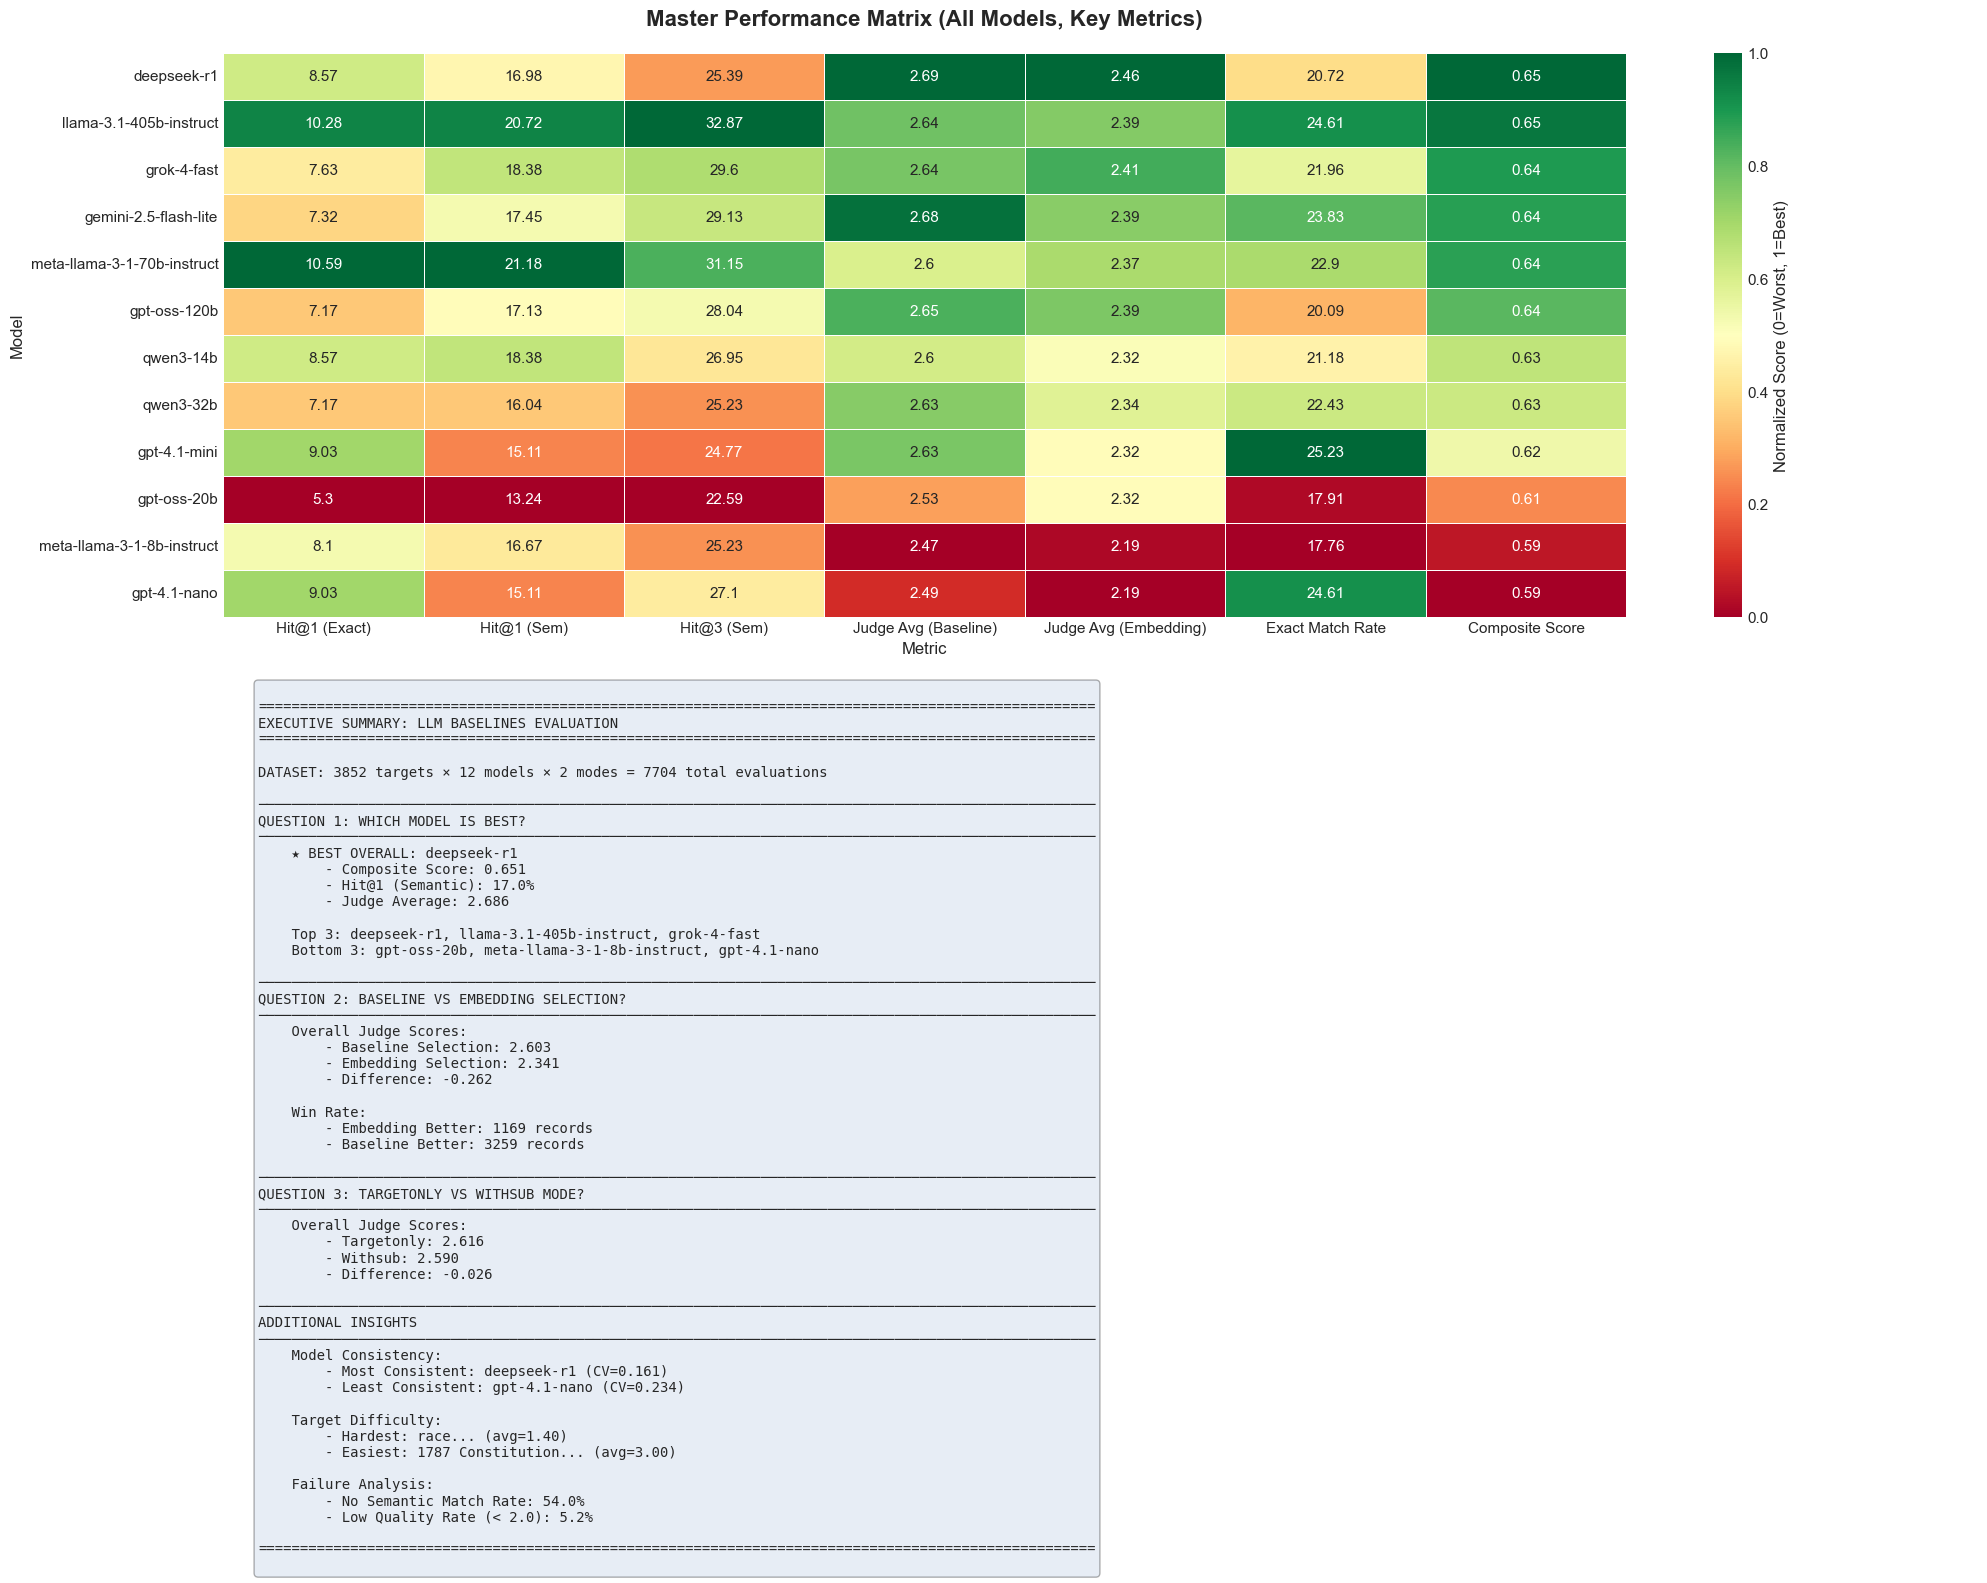


Summary dashboard generated and saved!


In [19]:
# Cell 9: Summary Dashboard

fig = plt.figure(figsize=(20, 16))

# =============================================================================
# Create Master Comparison Heatmap (top portion)
# =============================================================================
ax1 = fig.add_subplot(2, 1, 1)

# Prepare master metrics table
master_metrics = model_summary[['model', 'Hit@1 (Exact)', 'Hit@1 (Sem)', 'Hit@3 (Sem)', 
                                 'Judge Avg (Baseline)', 'Judge Avg (Embedding)', 
                                 'Exact Match Rate', 'Composite Score']].copy()

# Normalize scores to 0-1 for heatmap (higher = better)
normalized = master_metrics.copy()
for col in master_metrics.columns[1:]:
    col_min = master_metrics[col].min()
    col_max = master_metrics[col].max()
    normalized[col] = (master_metrics[col] - col_min) / (col_max - col_min) if col_max > col_min else 0.5

# Create heatmap data
heatmap_data = normalized.set_index('model')[['Hit@1 (Exact)', 'Hit@1 (Sem)', 'Hit@3 (Sem)', 
                                               'Judge Avg (Baseline)', 'Judge Avg (Embedding)',
                                               'Exact Match Rate', 'Composite Score']]
heatmap_data = heatmap_data.loc[model_order]

# Plot heatmap
sns.heatmap(heatmap_data, annot=master_metrics.set_index('model').loc[model_order][heatmap_data.columns].round(2),
            cmap='RdYlGn', center=0.5, linewidths=0.5, ax=ax1, fmt='',
            cbar_kws={'label': 'Normalized Score (0=Worst, 1=Best)'})

ax1.set_title('Master Performance Matrix (All Models, Key Metrics)', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Metric')
ax1.set_ylabel('Model')

# =============================================================================
# Key Findings Summary (bottom portion)
# =============================================================================
ax2 = fig.add_subplot(2, 1, 2)
ax2.axis('off')

# Compile key findings
findings_text = f"""
{'='*100}
EXECUTIVE SUMMARY: LLM BASELINES EVALUATION
{'='*100}

DATASET: {len(df)//2} targets × 12 models × 2 modes = {len(df)} total evaluations

{'─'*100}
QUESTION 1: WHICH MODEL IS BEST?
{'─'*100}
    ★ BEST OVERALL: {model_order[0]}
        - Composite Score: {model_summary[model_summary['model']==model_order[0]]['Composite Score'].values[0]:.3f}
        - Hit@1 (Semantic): {model_summary[model_summary['model']==model_order[0]]['Hit@1 (Sem)'].values[0]:.1f}%
        - Judge Average: {model_summary[model_summary['model']==model_order[0]]['Judge Avg (Baseline)'].values[0]:.3f}
    
    Top 3: {', '.join(model_order[:3])}
    Bottom 3: {', '.join(model_order[-3:])}

{'─'*100}
QUESTION 2: BASELINE VS EMBEDDING SELECTION?
{'─'*100}
    Overall Judge Scores:
        - Baseline Selection: {df['judge_baseline_avg'].mean():.3f}
        - Embedding Selection: {df['judge_embedding_avg'].mean():.3f}
        - Difference: {df['judge_embedding_avg'].mean() - df['judge_baseline_avg'].mean():.3f}
    
    Win Rate:
        - Embedding Better: {(df['judge_embedding_avg'] > df['judge_baseline_avg']).sum()} records
        - Baseline Better: {(df['judge_baseline_avg'] > df['judge_embedding_avg']).sum()} records

{'─'*100}
QUESTION 3: TARGETONLY VS WITHSUB MODE?
{'─'*100}
    Overall Judge Scores:
        - Targetonly: {df[df['mode']=='targetonly']['judge_baseline_avg'].mean():.3f}
        - Withsub: {df[df['mode']=='withsub']['judge_baseline_avg'].mean():.3f}
        - Difference: {df[df['mode']=='withsub']['judge_baseline_avg'].mean() - df[df['mode']=='targetonly']['judge_baseline_avg'].mean():.3f}

{'─'*100}
ADDITIONAL INSIGHTS
{'─'*100}
    Model Consistency:
        - Most Consistent: {cv_df.sort_values('cv').iloc[0]['model']} (CV={cv_df.sort_values('cv').iloc[0]['cv']:.3f})
        - Least Consistent: {cv_df.sort_values('cv').iloc[-1]['model']} (CV={cv_df.sort_values('cv').iloc[-1]['cv']:.3f})
    
    Target Difficulty:
        - Hardest: {target_stats.iloc[0]['target'][:40]}... (avg={target_stats.iloc[0]['avg_judge']:.2f})
        - Easiest: {target_stats.iloc[-1]['target'][:40]}... (avg={target_stats.iloc[-1]['avg_judge']:.2f})
    
    Failure Analysis:
        - No Semantic Match Rate: {(df['best_sem_rank']==-1).mean()*100:.1f}%
        - Low Quality Rate (< 2.0): {(df['judge_baseline_avg']<2.0).sum()/df['judge_baseline_avg'].notna().sum()*100:.1f}%

{'='*100}
"""

ax2.text(0.02, 0.98, findings_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor=COLORS['light'], alpha=0.3))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig7_summary_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\nSummary dashboard generated and saved!")

## Cell 10: Save Results

Export all summary data and list generated figures.

In [20]:
# Cell 10: Save Results

# =============================================================================
# Save Summary DataFrames
# =============================================================================

# 1. Model Summary (by model, aggregated across modes)
model_summary.to_csv(OUTPUT_DIR / 'model_summary.csv', index=False)
print(f"Saved: {OUTPUT_DIR / 'model_summary.csv'}")

# 2. Full Summary (by model and mode)
summary_df.to_csv(OUTPUT_DIR / 'summary_by_model_mode.csv', index=False)
print(f"Saved: {OUTPUT_DIR / 'summary_by_model_mode.csv'}")

# 3. Target Difficulty Analysis
target_stats.to_csv(OUTPUT_DIR / 'target_difficulty.csv', index=False)
print(f"Saved: {OUTPUT_DIR / 'target_difficulty.csv'}")

# 4. Model Consistency Analysis
cv_df.to_csv(OUTPUT_DIR / 'model_consistency.csv', index=False)
print(f"Saved: {OUTPUT_DIR / 'model_consistency.csv'}")

# 5. Failure Analysis
fail_df.to_csv(OUTPUT_DIR / 'failure_rates.csv', index=False)
print(f"Saved: {OUTPUT_DIR / 'failure_rates.csv'}")

# =============================================================================
# List Generated Figures
# =============================================================================
print("\n" + "=" * 80)
print("GENERATED FIGURES")
print("=" * 80)

figures = list(OUTPUT_DIR.glob('*.png'))
for fig_path in sorted(figures):
    print(f"  - {fig_path.name}")

# =============================================================================
# Summary Statistics for Export
# =============================================================================
print("\n" + "=" * 80)
print("KEY METRICS SUMMARY")
print("=" * 80)

summary_stats = {
    'Total Records': len(df),
    'Total Models': df['model'].nunique(),
    'Total Targets': df['target'].nunique(),
    
    # Best Model
    'Best Model (Composite)': model_order[0],
    'Best Model Score': model_summary[model_summary['model']==model_order[0]]['Composite Score'].values[0],
    
    # Overall Performance
    'Mean Judge (Baseline)': df['judge_baseline_avg'].mean(),
    'Mean Judge (Embedding)': df['judge_embedding_avg'].mean(),
    'Hit@1 (Exact) Overall': (df['best_exact_rank'] == 1).mean() * 100,
    'Hit@1 (Semantic) Overall': (df['best_sem_rank'] == 1).mean() * 100,
    
    # Mode Comparison
    'Targetonly Judge Avg': df[df['mode']=='targetonly']['judge_baseline_avg'].mean(),
    'Withsub Judge Avg': df[df['mode']=='withsub']['judge_baseline_avg'].mean(),
    
    # Failure Rates
    'No Exact Match Rate': (df['best_exact_rank'] == -1).mean() * 100,
    'No Semantic Match Rate': (df['best_sem_rank'] == -1).mean() * 100,
    'Low Quality Rate (< 2.0)': (df['judge_baseline_avg'] < 2.0).sum() / df['judge_baseline_avg'].notna().sum() * 100,
}

for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.3f}")
    else:
        print(f"  {key}: {value}")

# Save summary stats
summary_stats_df = pd.DataFrame([summary_stats])
summary_stats_df.to_csv(OUTPUT_DIR / 'key_metrics.csv', index=False)
print(f"\nSaved: {OUTPUT_DIR / 'key_metrics.csv'}")

print("\n" + "=" * 80)
print("ALL VISUALIZATIONS COMPLETE!")
print("=" * 80)
print(f"\nOutput directory: {OUTPUT_DIR.absolute()}")

Saved: results\visualizations\model_summary.csv
Saved: results\visualizations\summary_by_model_mode.csv
Saved: results\visualizations\target_difficulty.csv
Saved: results\visualizations\model_consistency.csv
Saved: results\visualizations\failure_rates.csv

GENERATED FIGURES
  - fig1_model_comparison.png
  - fig2_baseline_vs_embedding.png
  - fig3_targetonly_vs_withsub.png
  - fig4_model_consistency.png
  - fig5_target_difficulty.png
  - fig6_failure_analysis.png
  - fig7_summary_dashboard.png
  - figure1_exact_hitk.png
  - figure2_semantic_hitk.png
  - figure3_judge_scores.png
  - heatmaps_hit_judge.png

KEY METRICS SUMMARY
  Total Records: 7704
  Total Models: 12
  Total Targets: 321
  Best Model (Composite): deepseek-r1
  Best Model Score: 0.651
  Mean Judge (Baseline): 2.603
  Mean Judge (Embedding): 2.341
  Hit@1 (Exact) Overall: 8.229
  Hit@1 (Semantic) Overall: 17.199
  Targetonly Judge Avg: 2.616
  Withsub Judge Avg: 2.590
  No Exact Match Rate: 78.063
  No Semantic Match Rate: 